## Setup and Imports

In [1]:
import sys
sys.path.insert(0, 'backend_functions')

import selection_functions as sf
import importlib
import uproot
import matplotlib.pylab as pylab
import numpy as np
import pandas as pd
import math
from sklearn.model_selection import train_test_split
import xgboost as xgb
import awkward
import matplotlib.pyplot as plt

# Top is where parameters(ISRUN3) is defined
import top 
from top import *

# Reload modules to pick up any changes
importlib.reload(sf)
from selection_functions import *

importlib.reload(top)
from top import *

print("✅ Imports complete")

✅ Imports complete


## Configuration

Set up which run periods to include in training and other parameters.

In [2]:
# ============================================================================
# HORN CURRENT CONFIGURATION
# ============================================================================
# Set horn current mode: 'FHC' (Forward Horn Current) or 'RHC' (Reverse Horn Current)
# This will automatically configure which run periods to use based on file availability:
#   - RHC mode: Uses Run 4a, 4b, 4c (RHC files only)
#   - FHC mode: Uses Run 4c, 4d, 5 (FHC files only)

HORN_CURRENT = 'RHC'  # Options: 'FHC' or 'RHC'

# Automatically set run periods based on horn current
if HORN_CURRENT == 'RHC':
    RUN_PERIODS = {
        'run4a': True,   # RHC only
        'run4b': True,   # RHC only + EXT
        'run4c': True,   # RHC files
        'run4d': False,  # No RHC data
        'run5': False    # No RHC data
    }
    ISRUN3 = True  # RHC mode
elif HORN_CURRENT == 'FHC':
    RUN_PERIODS = {
        'run4a': False,  # No FHC data
        'run4b': False,  # No FHC data
        'run4c': True,   # FHC files
        'run4d': True,   # FHC only
        'run5': True     # FHC only
    }
    ISRUN3 = False  # FHC mode
else:
    raise ValueError(f"Unknown HORN_CURRENT: {HORN_CURRENT}. Must be 'FHC' or 'RHC'")

# Other configuration
NUE_INTRINSIC = True
TRAIN_TEST_SPLIT = 0.5  # Use 50% for training, 50% for testing per run
USE_EXT_IN_BDT = False  # Whether to include EXT data in BDT training
EVENT_SPLIT_SEED = 17  # Seed for event-ID-based splitting

print("=" * 70)
print(f"🎯 HORN CURRENT MODE: {HORN_CURRENT}")
print("=" * 70)
print(f"Training configuration:")
print(f"  Run periods to include: {[k for k, v in RUN_PERIODS.items() if v]}")
print(f"  Train/Test split: {int((1-TRAIN_TEST_SPLIT)*100)}% train / {int(TRAIN_TEST_SPLIT*100)}% test")
print(f"  Use EXT in BDT: {USE_EXT_IN_BDT}")
print(f"  Event split seed: {EVENT_SPLIT_SEED}")
print(f"  ISRUN3 flag: {ISRUN3}")
print("=" * 70)


🎯 HORN CURRENT MODE: RHC
Training configuration:
  Run periods to include: ['run4a', 'run4b', 'run4c']
  Train/Test split: 50% train / 50% test
  Use EXT in BDT: False
  Event split seed: 17
  ISRUN3 flag: True


In [3]:
# Base path
base_path = "/pnfs/uboone/persistent/users/uboonepro/surprise/"

# ============================================================================
# FILE NAMING PATTERNS
# ============================================================================
# Define file patterns for each run period and horn current mode
# Based on actual file availability:
# - Run 4a: RHC only (overlay, nue, dirt), no EXT
# - Run 4b: RHC only (overlay, nue, dirt), EXT available
# - Run 4c: BOTH FHC and RHC (overlay, nue, dirt), no EXT
# - Run 4d: FHC only (overlay, nue, dirt), no EXT
# - Run 5:  FHC only (overlay, nue, dirt), no EXT

def get_file_paths(horn_current):
    """
    Get file paths for the specified horn current mode.
    
    Parameters:
    -----------
    horn_current : str
        'FHC' or 'RHC'
        
    Returns:
    --------
    dict : Dictionary of run periods with file paths
        Keys: run period names
        Values: dict with 'OVRLY', 'NUE', 'DIRT', and optionally 'EXT' keys
    """
    if horn_current == 'RHC':
        # RHC file paths
        return {
            'run4a': {
                'OVRLY': 'run4a_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4a4c_NuMI_RHC_nu_overlay_surprise_reco2_hist_4a',
                'NUE': 'run4a_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4a4c_NuMI_RHC_intrinsic_nue_overlay_surprise_reco2_hist_4a',
                'DIRT': 'run4a_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4a4c_NuMI_RHC_dirt_overlay_surprise_reco2_hist_4a'
                # No EXT available for run4a yet
            },
            'run4b': {
                'OVRLY': 'run4b_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4b_NuMI_RHC_nu_overlay_surprise_v10_04_07_09_reco2_hist',
                'NUE': 'run4b_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4b_NuMI_RHC_nue_overlay_surprise_v10_04_07_09_reco2_hist',
                'DIRT': 'run4b_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4a4c_NuMI_RHC_dirt_overlay_surprise_reco2_hist_4b',
                'EXT': 'run4b_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4b_NuMI_beam_off_RHC_data_surprise_v10_04_07_09_reco2_hist'  # Horn current independent
            },
            'run4c': {
                'OVRLY': 'run4c_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4a4c_NuMI_RHC_nu_overlay_surprise_reco2_hist_4c',
                'NUE': 'run4c_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4a4c_NuMI_RHC_intrinsic_nue_overlay_surprise_reco2_hist_4c',
                'DIRT': 'run4c_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4a4c_NuMI_RHC_dirt_overlay_surprise_reco2_hist_4c'
                # No EXT available for run4c yet
            }
            # Run 4d and Run 5 do not have RHC data
        }
    elif horn_current == 'FHC':
        # FHC file paths
        return {
            'run4c': {
                'OVRLY': 'run4c_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4c4d5_NuMI_FHC_nu_overlay_surprise_reco2_hist_4c',
                'NUE': 'run4c_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4c4d5_NuMI_FHC_intrinsic_nue_overlay_surprise_reco2_hist_4c',
                'DIRT': 'run4c_full_samples/wc_processed/NuMI/checkout_prodgenie_numi_fhc_dirt_new_flux_overlay_run_4cd_5_reco2_reco2_hist_4c'
                # No EXT available for run4c yet
            },
            'run4d': {
                'OVRLY': 'run4d_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4c4d5_NuMI_FHC_nu_overlay_surprise_reco2_hist_4d',
                'NUE': 'run4d_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4c4d5_NuMI_FHC_intrinsic_nue_overlay_surprise_reco2_hist_4d',
                'DIRT': 'run4d_full_samples/wc_processed/NuMI/checkout_prodgenie_numi_fhc_dirt_new_flux_overlay_run_4cd_5_reco2_reco2_hist_4d'
                # No EXT available for run4d yet
            },
            'run5': {
                'OVRLY': 'run5_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4c4d5_NuMI_FHC_nu_overlay_surprise_reco2_hist_5',
                'NUE': 'run5_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4c4d5_NuMI_FHC_intrinsic_nue_overlay_surprise_reco2_hist_5',
                'DIRT': 'run5_full_samples/wc_processed/NuMI/checkout_prodgenie_numi_fhc_dirt_new_flux_overlay_run_4cd_5_reco2_reco2_hist_5'
                # No EXT available for run5 yet
            }
            # Run 4a and Run 4b do not have FHC data
        }
    else:
        raise ValueError(f"Unknown horn current mode: {horn_current}. Must be 'FHC' or 'RHC'")


# Get file paths for the selected horn current
RUN_FILES = get_file_paths(HORN_CURRENT)

fold = "nuselection"
tree = "NeutrinoSelectionFilter"

print(f"\n✅ File paths configured for {HORN_CURRENT} mode")
print(f"   Available run periods: {list(RUN_FILES.keys())}")
print("⚠️  Note: Update FHC file paths in get_file_paths() function if needed")


✅ File paths configured for RHC mode
   Available run periods: ['run4a', 'run4b', 'run4c']
⚠️  Note: Update FHC file paths in get_file_paths() function if needed


In [4]:
# ============================================================================
# POT (Protons On Target) VALUES
# ============================================================================
# POT values for each run period - used for proper event weighting and normalization
# These are the beam-on data POT values

POT_VALUES = {
    'run4a': {
        'FHC': None,           # No FHC data for Run 4a
        'RHC': 8.312e+18       # 8.312E18
    },
    'run4b': {
        'FHC': None,           # No FHC data for Run 4b
        'RHC': 2.527e+20       # 2.527E20 (actual value, not scaled)
    },
    'run4c': {
        'FHC': 1.214e+20,      # 1.214E20
        'RHC': 1.688e+19       # 1.688E19
    },
    'run4d': {
        'FHC': 6.832e+19,      # 6.832E19
        'RHC': None            # No RHC data for Run 4d
    },
    'run5': {
        'FHC': 2.162e+20,      # 2.162E20
        'RHC': None            # No RHC data for Run 5
    }
}

# Get POT value for current horn current mode
def get_pot_for_run(run_name, horn_current):
    """Get the POT value for a specific run and horn current."""
    if run_name in POT_VALUES and POT_VALUES[run_name][horn_current] is not None:
        return POT_VALUES[run_name][horn_current]
    else:
        raise ValueError(f"No POT value available for {run_name} in {horn_current} mode")

# Display POT values for enabled runs
print("\n" + "=" * 70)
print("📊 POT VALUES FOR SELECTED RUNS")
print("=" * 70)
for run_name, enabled in RUN_PERIODS.items():
    if enabled and run_name in RUN_FILES:
        pot = POT_VALUES[run_name][HORN_CURRENT]
        print(f"  {run_name} ({HORN_CURRENT}): {pot:.3e}")
print("=" * 70)



📊 POT VALUES FOR SELECTED RUNS
  run4a (RHC): 8.312e+18
  run4b (RHC): 2.527e+20
  run4c (RHC): 1.688e+19


## Load Data from All Run Periods

Load files from each enabled run period.

In [5]:
def load_run_period(run_name, file_dict, include_nue=True):
    """
    Load all files for a single run period.
    ⚠️ DATA files excluded (blind analysis)
    
    Parameters:
    -----------
    run_name : str
        Name of the run period (e.g., 'run4a')
    file_dict : dict
        Dictionary containing file paths for this run
        Keys: 'OVRLY', 'NUE', 'DIRT', and optionally 'EXT'
    include_nue : bool
        Whether to include nue intrinsic sample
        
    Returns:
    --------
    list : List of uproot trees [overlay, ext (if available), nue (if requested), dirt]
    """
    print(f"\n📂 Loading {run_name}...")
    
    try:
        uproot_v = []
        file_types = []
        
        # Always load overlay
        overlay = uproot.open(base_path + file_dict['OVRLY'] + ".root")[fold][tree]
        uproot_v.append(overlay)
        file_types.append('overlay')
        
        # Load EXT if available and requested
        if 'EXT' in file_dict and USE_EXT_IN_BDT:
            ext = uproot.open(base_path + file_dict['EXT'] + ".root")[fold][tree]
            uproot_v.append(ext)
            file_types.append('ext')
        elif 'EXT' not in file_dict:
            print(f"   ⚠️  No EXT file available for {run_name}")
        
        # Load NUE if requested
        if include_nue and 'NUE' in file_dict:
            nue = uproot.open(base_path + file_dict['NUE'] + ".root")[fold][tree]
            uproot_v.append(nue)
            file_types.append('nue')
            
        # Load DIRT if available
        if 'DIRT' in file_dict:
            dirt = uproot.open(base_path + file_dict['DIRT'] + ".root")[fold][tree]
            uproot_v.append(dirt)
            file_types.append('dirt')
        else:
            print(f"   ⚠️  No DIRT file available for {run_name}")
            
        print(f"   ✅ Loaded: {', '.join(file_types)}")
        print(f"   ⚠️  DATA files excluded (blind analysis)")
        return uproot_v
        
    except Exception as e:
        print(f"   ❌ Error loading {run_name}: {e}")
        return None


# Load all enabled run periods
all_run_data = {}

for run_name, enabled in RUN_PERIODS.items():
    if enabled:
        # Check if this run exists in the file paths
        if run_name in RUN_FILES:
            run_data = load_run_period(run_name, RUN_FILES[run_name], include_nue=NUE_INTRINSIC)
            if run_data is not None:
                all_run_data[run_name] = run_data
        else:
            print(f"\n⚠️  Run {run_name} not available for {HORN_CURRENT} mode")

print(f"\n✅ Successfully loaded {len(all_run_data)} run period(s)")


📂 Loading run4a...
   ⚠️  No EXT file available for run4a
   ✅ Loaded: overlay, nue, dirt
   ⚠️  DATA files excluded (blind analysis)

📂 Loading run4b...
   ✅ Loaded: overlay, nue, dirt
   ⚠️  DATA files excluded (blind analysis)

📂 Loading run4c...
   ⚠️  No EXT file available for run4c
   ✅ Loaded: overlay, nue, dirt
   ⚠️  DATA files excluded (blind analysis)

✅ Successfully loaded 3 run period(s)


In [6]:
# Track file types for each run period
# This is needed to know which files were loaded for each run
all_file_types = {}

for run_name in all_run_data.keys():
    file_types = ['overlay']  # Always have overlay
    
    if 'EXT' in RUN_FILES[run_name] and USE_EXT_IN_BDT:
        file_types.append('ext')
    
    if NUE_INTRINSIC and 'NUE' in RUN_FILES[run_name]:
        file_types.append('nue')
    
    if 'DIRT' in RUN_FILES[run_name]:
        file_types.append('dirt')
    
    all_file_types[run_name] = file_types

print(f"\n📋 File types loaded for each run:")
for run_name, ftypes in all_file_types.items():
    print(f"  {run_name}: {', '.join(ftypes)}")


📋 File types loaded for each run:
  run4a: overlay, nue, dirt
  run4b: overlay, nue, dirt
  run4c: overlay, nue, dirt


## Load Variables and Apply Preselection

Load the necessary variables for BDT training from each run period.

In [7]:
# Get variable list from top.py and add required variables
# Need to load raw variables from ROOT files before computing derived ones

# Variables needed from ROOT files (not yet computed)
root_variables = [
    'run', 'sub', 'evt',  # Event IDs
    'swtrig_pre',  # Software trigger
    'slice_orig_pass_id',  # Slice selection
    # Reco vertex
    'reco_nu_vtx_sce_x', 'reco_nu_vtx_sce_y', 'reco_nu_vtx_sce_z',
    # Truth info (MC only)
    'nu_pdg', 'ccnc', 'nu_e',
    'true_nu_vtx_x', 'true_nu_vtx_y', 'true_nu_vtx_z',
    'npi0', 'npion', 'nproton', 'elec_e',
    # Reco variables
    'n_tracks_contained', 'n_showers_contained',
    'trk_energy', 'shr_energy_tot_cali', 'shr_energy_cali',
    'contained_fraction', 'shrmoliereavg',
    'tksh_distance', 'tksh_angle', 'trkshrhitdist2',
    'NeutrinoEnergy2',  # Needed for NeutrinoEnergy2_GeV calculation
    # dE/dx variables
    'shr_tkfit_dedx_Y', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_2cm_dedx_Y',
    # Subcluster components (need these to compute 'subcluster')
    'shrsubclusters0', 'shrsubclusters1', 'shrsubclusters2',
    # NuGraph variables (raw from file)
    'ng2hip_r1cm', 'ng2hip_r10cm',
    # Weight variables (MC only)
    'weightSpline', 'weightSplineTimesTune', 'weightTune', 'ppfx_cv',
]

# Variables that will be computed after loading (trkpid, pfng2*, subcluster, pot_scale, totweight_data)
# These are NOT in the ROOT files and must be computed

# Remove duplicates
variables = list(set(root_variables))

print(f"Loading {len(variables)} raw variables from ROOT files...")
print(f"First 10: {variables[:10]}")
print(f"\n⚠️  Note: Derived variables (trkpid, pfng2*, subcluster) will be computed after loading")

Loading 41 raw variables from ROOT files...
First 10: ['ng2hip_r1cm', 'true_nu_vtx_x', 'npion', 'ccnc', 'tksh_angle', 'shr_energy_cali', 'shrmoliereavg', 'ppfx_cv', 'trk_energy', 'shr_tkfit_dedx_Y']

⚠️  Note: Derived variables (trkpid, pfng2*, subcluster) will be computed after loading


In [8]:
def load_variables_from_run(uproot_trees, variables, file_types):
    """
    Load variables from uproot trees for a run period.
    
    Parameters:
    -----------
    uproot_trees : list
        List of uproot trees (overlay, ext if available, nue if requested, dirt)
    variables : list
        List of variable names to load
    file_types : list
        Names of the file types corresponding to uproot_trees
        
    Returns:
    --------
    tuple : (datasets, file_types)
        datasets: List of DataFrames
        file_types: List of corresponding type names
    """
    datasets = []
    
    for i, tree in enumerate(uproot_trees):
        try:
            # Load variables that exist in the tree
            available_vars = [v for v in variables if v in tree.keys()]
            df = tree.arrays(available_vars, library="pd")
            datasets.append(df)
            print(f"   ✅ {file_types[i]}: {len(df):,} events, {len(available_vars)} variables")
        except Exception as e:
            print(f"   ❌ Error loading {file_types[i]}: {e}")
            
    return datasets, file_types


# Load variables from all run periods
all_datasets = {}

for run_name, uproot_trees in all_run_data.items():
    print(f"\n📊 Loading variables for {run_name}:")
    file_types = all_file_types[run_name]
    datasets, _ = load_variables_from_run(uproot_trees, variables, file_types)
    all_datasets[run_name] = datasets


print(f"\n✅ Loaded variables from {len(all_datasets)} run period(s)")


📊 Loading variables for run4a:
   ✅ overlay: 188,845 events, 41 variables
   ✅ nue: 54,842 events, 41 variables
   ✅ dirt: 31,060 events, 41 variables

📊 Loading variables for run4b:
   ✅ overlay: 612,983 events, 41 variables
   ✅ nue: 187,037 events, 41 variables
   ✅ dirt: 99,506 events, 41 variables

📊 Loading variables for run4c:
   ✅ overlay: 38,533 events, 41 variables
   ✅ nue: 11,390 events, 41 variables
   ✅ dirt: 6,191 events, 41 variables

✅ Loaded variables from 3 run period(s)


## Compute Derived Variables

Compute NuGraph variables, trkpid, and other derived variables that are needed for BDT training (same as selection.ipynb).

In [9]:
# Define functions to compute NuGraph variables and trkpid from uproot trees
# These are the same functions used in selection.ipynb

def compute_trkpid(up):
    """Compute track PID score from LLR PID scores"""
    arrs = up.arrays(['trk_llr_pid_score_v', 'trk_id'], library='np')
    pid_v = arrs['trk_llr_pid_score_v']
    tid = arrs['trk_id'].astype('int64') - 1  # convert to 0-based
    out = []
    for pid, t in zip(pid_v, tid):
        ti = int(t)
        if 0 <= ti < len(pid):
            out.append(float(pid[ti]))
        else:
            out.append(9999.0)
    return out

def compute_pfng2hipavrg(up):
    """NuGraph HIP average for track"""
    arrs = up.arrays(['pfng2hipavrg', 'trk_id'], library='np')
    sem_v = arrs['pfng2hipavrg']
    tid = arrs['trk_id'].astype('int64') - 1
    out = []
    for sem, t in zip(sem_v, tid):
        ti = int(t)
        if 0 <= ti < len(sem):
            out.append(float(sem[ti]))
        else:
            out.append(9999.0)
    return out

def compute_pfng2shravrg(up):
    """NuGraph shower average for shower"""
    arrs = up.arrays(['pfng2shravrg', 'shr_id'], library='np')
    sem_v = arrs['pfng2shravrg']
    tid = arrs['shr_id'].astype('int64') - 1
    out = []
    for sem, t in zip(sem_v, tid):
        ti = int(t)
        if 0 <= ti < len(sem):
            out.append(float(sem[ti]))
        else:
            out.append(9999.0)
    return out

def compute_pfng2hipfrac(up):
    """NuGraph HIP fraction for track"""
    arrs = up.arrays(['pfng2hipfrac', 'trk_id'], library='np')
    sem_v = arrs['pfng2hipfrac']
    tid = arrs['trk_id'].astype('int64') - 1
    out = []
    for sem, t in zip(sem_v, tid):
        ti = int(t)
        if 0 <= ti < len(sem):
            out.append(float(sem[ti]))
        else:
            out.append(9999.0)
    return out

def compute_pfng2shrfrac(up):
    """NuGraph shower fraction for shower"""
    arrs = up.arrays(['pfng2shrfrac', 'shr_id'], library='np')
    sem_v = arrs['pfng2shrfrac']
    tid = arrs['shr_id'].astype('int64') - 1
    out = []
    for sem, t in zip(sem_v, tid):
        ti = int(t)
        if 0 <= ti < len(sem):
            out.append(float(sem[ti]))
        else:
            out.append(9999.0)
    return out

print("✅ Variable computation functions defined")

✅ Variable computation functions defined


In [10]:
# Compute NuGraph variables and trkpid for each run period
# Apply to overlay and nue (not EXT - no MC truth info)

print("=" * 70)
print("🔬 COMPUTING DERIVED VARIABLES")
print("=" * 70)
print()

for run_name in all_run_data.keys():
    print(f"📊 Computing variables for {run_name}...")
    
    uproot_trees = all_run_data[run_name]
    datasets = all_datasets[run_name]
    file_types = all_file_types[run_name]
    
    for i, (df, uproot_tree, file_type) in enumerate(zip(datasets, uproot_trees, file_types)):
        # Only compute for MC samples (overlay, nue, dirt) - not EXT
        if file_type in ['overlay', 'nue', 'dirt']:
            print(f"   Computing for {file_type}...")
            
            # Compute NuGraph and trkpid variables
            df['trkpid'] = compute_trkpid(uproot_tree)
            df['pfng2hipavrg'] = compute_pfng2hipavrg(uproot_tree)
            df['pfng2shravrg'] = compute_pfng2shravrg(uproot_tree)
            df['pfng2hipfrac'] = compute_pfng2hipfrac(uproot_tree)
            df['pfng2shrfrac'] = compute_pfng2shrfrac(uproot_tree)
            
            # Compute subcluster (sum of subclusters)
            df['subcluster'] = df['shrsubclusters0'] + df['shrsubclusters1'] + df['shrsubclusters2']
            
            print(f"      ✅ Added: trkpid, pfng2hipavrg, pfng2shravrg, pfng2hipfrac, pfng2shrfrac, subcluster")
        
        # Update the dataset in all_datasets
        all_datasets[run_name][i] = df
    
    print()

print("=" * 70)
print("✅ Derived variable computation complete!")
print("=" * 70)

🔬 COMPUTING DERIVED VARIABLES

📊 Computing variables for run4a...
   Computing for overlay...
      ✅ Added: trkpid, pfng2hipavrg, pfng2shravrg, pfng2hipfrac, pfng2shrfrac, subcluster
   Computing for nue...
      ✅ Added: trkpid, pfng2hipavrg, pfng2shravrg, pfng2hipfrac, pfng2shrfrac, subcluster
   Computing for dirt...
      ✅ Added: trkpid, pfng2hipavrg, pfng2shravrg, pfng2hipfrac, pfng2shrfrac, subcluster

📊 Computing variables for run4b...
   Computing for overlay...
      ✅ Added: trkpid, pfng2hipavrg, pfng2shravrg, pfng2hipfrac, pfng2shrfrac, subcluster
   Computing for nue...
      ✅ Added: trkpid, pfng2hipavrg, pfng2shravrg, pfng2hipfrac, pfng2shrfrac, subcluster
   Computing for dirt...
      ✅ Added: trkpid, pfng2hipavrg, pfng2shravrg, pfng2hipfrac, pfng2shrfrac, subcluster

📊 Computing variables for run4c...
   Computing for overlay...
      ✅ Added: trkpid, pfng2hipavrg, pfng2shravrg, pfng2hipfrac, pfng2shrfrac, subcluster
   Computing for nue...
      ✅ Added: trkpid, pfn

## Apply Common Derived Columns

Apply energy calibrations and other common derived columns that are applied to ALL samples in selection.ipynb (including EXT).

In [11]:
# Apply common derived columns to ALL samples (MC and EXT)
# Following selection.ipynb lines 450-456

print("=" * 70)
print("🔬 APPLYING COMMON DERIVED COLUMNS")
print("=" * 70)
print()

for run_name in all_datasets.keys():
    print(f"📊 Processing {run_name}...")
    
    datasets = all_datasets[run_name]
    file_types = all_file_types[run_name]
    
    for i, (df, file_type) in enumerate(zip(datasets, file_types)):
        # Apply to ALL samples (overlay, ext, nue, dirt, data if present)
        print(f"   Applying to {file_type}...")
        
        # Energy calibrations
        df['shr_energy_cali'] = df['shr_energy_cali'] / 0.83
        df['NeutrinoEnergy2_GeV'] = df['NeutrinoEnergy2'] / 1000.0
        
        print(f"      ✅ Applied: shr_energy_cali/0.83, NeutrinoEnergy2_GeV")
        
        # Update the dataset
        all_datasets[run_name][i] = df
    
    print()

print("=" * 70)
print("✅ Common derived columns applied!")
print("=" * 70)

🔬 APPLYING COMMON DERIVED COLUMNS

📊 Processing run4a...
   Applying to overlay...
      ✅ Applied: shr_energy_cali/0.83, NeutrinoEnergy2_GeV
   Applying to nue...
      ✅ Applied: shr_energy_cali/0.83, NeutrinoEnergy2_GeV
   Applying to dirt...
      ✅ Applied: shr_energy_cali/0.83, NeutrinoEnergy2_GeV

📊 Processing run4b...
   Applying to overlay...
      ✅ Applied: shr_energy_cali/0.83, NeutrinoEnergy2_GeV
   Applying to nue...
      ✅ Applied: shr_energy_cali/0.83, NeutrinoEnergy2_GeV
   Applying to dirt...
      ✅ Applied: shr_energy_cali/0.83, NeutrinoEnergy2_GeV

📊 Processing run4c...
   Applying to overlay...
      ✅ Applied: shr_energy_cali/0.83, NeutrinoEnergy2_GeV
   Applying to nue...
      ✅ Applied: shr_energy_cali/0.83, NeutrinoEnergy2_GeV
   Applying to dirt...
      ✅ Applied: shr_energy_cali/0.83, NeutrinoEnergy2_GeV

✅ Common derived columns applied!


## Clean Weights and Add is_signal

Clean bad weight values and add the is_signal flag (same as selection.ipynb).

In [12]:
# Clean bad weights and add is_signal flag for MC samples
# Following selection.ipynb approach

print("=" * 70)
print("🧹 CLEANING WEIGHTS AND ADDING is_signal FLAG")
print("=" * 70)
print()

for run_name in all_datasets.keys():
    print(f"📊 Processing {run_name}...")
    
    datasets = all_datasets[run_name]
    file_types = all_file_types[run_name]
    
    for i, (df, file_type) in enumerate(zip(datasets, file_types)):
        # Only for MC samples (overlay, nue, dirt)
        if file_type in ['overlay', 'nue', 'dirt']:
            print(f"   Cleaning {file_type}...")
            
            # Clean bad weights (same as selection.ipynb)
            for weight_var in ['ppfx_cv', 'weightSplineTimesTune', 'weightTune']:
                if weight_var in df.columns:
                    df.loc[df[weight_var] <= 0, weight_var] = 1.0
                    df.loc[df[weight_var] == np.inf, weight_var] = 1.0
                    df.loc[df[weight_var] > 30, weight_var] = 1.0
                    df.loc[np.isnan(df[weight_var]), weight_var] = 1.0
            
            # Add is_signal flag (same definition as selection.ipynb)
            df['is_signal'] = np.where(
                (df['nu_pdg'] == 12) & 
                (df['ccnc'] == 0) & 
                (df['nproton'] > 0) & 
                (df['npion'] == 0) & 
                (df['npi0'] == 0) &
                (10 <= df['true_nu_vtx_x']) & (df['true_nu_vtx_x'] <= 246) &
                (-106 <= df['true_nu_vtx_y']) & (df['true_nu_vtx_y'] <= 106) &
                (10 <= df['true_nu_vtx_z']) & (df['true_nu_vtx_z'] <= 1026) &
                (df['elec_e'] > 0.07),  # Electron energy threshold
                True, False
            )
            
            n_signal = df['is_signal'].sum()
            print(f"      ✅ Cleaned weights, added is_signal ({n_signal:,} signal events)")
        
        # Update dataset
        all_datasets[run_name][i] = df
    
    print()

print("=" * 70)
print("✅ Weight cleaning and is_signal complete!")
print("=" * 70)

🧹 CLEANING WEIGHTS AND ADDING is_signal FLAG

📊 Processing run4a...
   Cleaning overlay...
      ✅ Cleaned weights, added is_signal (888 signal events)
   Cleaning nue...
      ✅ Cleaned weights, added is_signal (19,154 signal events)
   Cleaning dirt...
      ✅ Cleaned weights, added is_signal (0 signal events)

📊 Processing run4b...
   Cleaning overlay...
      ✅ Cleaned weights, added is_signal (2,942 signal events)
   Cleaning nue...
      ✅ Cleaned weights, added is_signal (65,133 signal events)
   Cleaning dirt...
      ✅ Cleaned weights, added is_signal (0 signal events)

📊 Processing run4c...
   Cleaning overlay...
      ✅ Cleaned weights, added is_signal (197 signal events)
   Cleaning nue...
      ✅ Cleaned weights, added is_signal (3,892 signal events)
   Cleaning dirt...
      ✅ Cleaned weights, added is_signal (0 signal events)

✅ Weight cleaning and is_signal complete!


## MC POT Values

Each MC sample (overlay, nue intrinsic, dirt) was generated with its own POT. 
We need these values to calculate `pot_scale` for proper normalization.

In [13]:
# ============================================================================
# MC GENERATION POT VALUES
# ============================================================================
# POT values used when generating each MC sample type
# These are needed to calculate pot_scale = beamon_pot / mc_generation_pot

MC_GENERATION_POT = {
    'run4a': {
        'RHC': {
            'overlay': 7.20478e+20,
            'nue': 1.49847e+22,
            'dirt': 1.3077e+20
        },
        'FHC': {
            'overlay': None,      # No FHC for Run 4a
            'nue': None,
            'dirt': None
        }
    },
    'run4b': {
        'RHC': {
            'overlay': 2.33807e+21,
            'nue': 5.04447e+22,
            'dirt': 4.20894e+20
        },
        'FHC': {
            'overlay': None,      # No FHC for Run 4b
            'nue': None,
            'dirt': None
        }
    },
    'run4c': {
        'RHC': {
            'overlay': 1.47086e+20,
            'nue': 3.07874e+21,
            'dirt': 2.60777e+19
        },
        'FHC': {
            'overlay': 1.05787e+21,
            'nue': 2.36381e+22,
            'dirt': 2.15437e+20
        }
    },
    'run4d': {
        'RHC': {
            'overlay': None,      # No RHC for Run 4d
            'nue': None,
            'dirt': None
        },
        'FHC': {
            'overlay': 1.69211e+21,
            'nue': 4.95459e+22,
            'dirt': 3.4002e+20
        }
    },
    'run5': {
        'RHC': {
            'overlay': None,      # No RHC for Run 5
            'nue': None,
            'dirt': None
        },
        'FHC': {
            'overlay': 2.61871e+21,
            'nue': 6.01751e+22,
            'dirt': 4.95156e+20
        }
    }
}

print("=" * 70)
print("📋 MC GENERATION POT VALUES NEEDED")
print("=" * 70)
print("\n⚠️  TODO: Fill in MC generation POT values for enabled runs")
print("\nFor each enabled run, you need:")
print("  - Overlay generation POT")
print("  - Nue intrinsic generation POT")
print("  - Dirt generation POT (if using dirt)")
print("\nThese values are typically found in:")
print("  - SAM metadata for the MC samples")
print("  - Production documentation")
print("  - metadata.txt files in the sample directories")
print("=" * 70)

📋 MC GENERATION POT VALUES NEEDED

⚠️  TODO: Fill in MC generation POT values for enabled runs

For each enabled run, you need:
  - Overlay generation POT
  - Nue intrinsic generation POT
  - Dirt generation POT (if using dirt)

These values are typically found in:
  - SAM metadata for the MC samples
  - Production documentation
  - metadata.txt files in the sample directories


## Calculate pot_scale for Each Dataset

Now calculate `pot_scale` for each MC sample: `pot_scale = beamon_pot / mc_generation_pot`

In [14]:
def calculate_pot_scale(datasets, run_name, horn_current, file_types):
    """
    Calculate and add pot_scale column to each dataset.
    
    pot_scale = beamon_pot / mc_generation_pot
    
    This normalizes each MC sample to the beam-on data POT for that run.
    
    Parameters:
    -----------
    datasets : list of DataFrames
        List of datasets for this run (overlay, ext, nue, dirt)
    run_name : str
        Name of the run period (e.g., 'run4b')
    horn_current : str
        'FHC' or 'RHC'
    file_types : list
        Names of file types corresponding to datasets
        
    Returns:
    --------
    list of DataFrames : Datasets with pot_scale column added
    """
    # Get beam-on POT for this run
    beamon_pot = POT_VALUES[run_name][horn_current]
    
    print(f"   {run_name} ({horn_current}):")
    print(f"      Beam-on POT: {beamon_pot:.3e}")
    
    scaled_datasets = []
    
    for i, df in enumerate(datasets):
        df_scaled = df.copy()
        file_type = file_types[i]
        
        # Skip EXT - it doesn't use POT scaling (uses trigger ratio instead)
        if file_type == 'ext':
            # For EXT, we would need trigger counts instead
            # For now, set pot_scale = 1 (will need proper EXT scaling later)
            df_scaled['pot_scale'] = 1.0
            print(f"      {file_type}: pot_scale set to 1.0 (needs trigger ratio)")
            scaled_datasets.append(df_scaled)
            continue
        
        # For MC samples (overlay, nue, dirt)
        mc_gen_pot = MC_GENERATION_POT[run_name][horn_current].get(file_type)
        
        if mc_gen_pot is None:
            raise ValueError(
                f"Missing MC generation POT for {run_name} {horn_current} {file_type}. "
                f"Please fill in MC_GENERATION_POT dictionary above."
            )
        
        # Calculate pot_scale
        pot_scale = beamon_pot / mc_gen_pot
        df_scaled['pot_scale'] = pot_scale
        
        print(f"      {file_type}: MC gen POT = {mc_gen_pot:.3e}, pot_scale = {pot_scale:.6f}")
        
        scaled_datasets.append(df_scaled)
    
    return scaled_datasets


# Apply pot_scale calculation to all datasets
print("=" * 70)
print("🔬 CALCULATING POT_SCALE FOR EACH DATASET")
print("=" * 70)
print()

all_datasets_with_pot_scale = {}

for run_name, datasets in all_datasets.items():
    file_types = all_file_types[run_name]
    
    try:
        scaled_datasets = calculate_pot_scale(
            datasets, 
            run_name, 
            HORN_CURRENT, 
            file_types
        )
        all_datasets_with_pot_scale[run_name] = scaled_datasets
        print()
        
    except ValueError as e:
        print(f"\n❌ Error: {e}")
        print("\nPlease fill in the MC_GENERATION_POT values and rerun this cell.")
        raise

# Replace datasets with pot_scale versions
all_datasets = all_datasets_with_pot_scale

print("=" * 70)
print("✅ pot_scale calculation complete!")
print("=" * 70)

🔬 CALCULATING POT_SCALE FOR EACH DATASET

   run4a (RHC):
      Beam-on POT: 8.312e+18
      overlay: MC gen POT = 7.205e+20, pot_scale = 0.011537
      nue: MC gen POT = 1.498e+22, pot_scale = 0.000555
      dirt: MC gen POT = 1.308e+20, pot_scale = 0.063562

   run4b (RHC):
      Beam-on POT: 2.527e+20
      overlay: MC gen POT = 2.338e+21, pot_scale = 0.108081
      nue: MC gen POT = 5.044e+22, pot_scale = 0.005009
      dirt: MC gen POT = 4.209e+20, pot_scale = 0.600389

   run4c (RHC):
      Beam-on POT: 1.688e+19
      overlay: MC gen POT = 1.471e+20, pot_scale = 0.114763
      nue: MC gen POT = 3.079e+21, pot_scale = 0.005483
      dirt: MC gen POT = 2.608e+19, pot_scale = 0.647296

✅ pot_scale calculation complete!


## Calculate totweight_data

Calculate the combined weight that will be used in BDT training:
`totweight_data = pot_scale * ppfx_cv * weightSplineTimesTune`

This is the actual weight variable that will be used for MC samples in the BDT.

In [15]:
# Calculate totweight_data for all MC samples
# This is the weight used in BDT training: pot_scale * ppfx_cv * weightSplineTimesTune

print("=" * 70)
print("🔬 CALCULATING totweight_data FOR BDT TRAINING")
print("=" * 70)
print()

for run_name in all_datasets.keys():
    print(f"📊 Processing {run_name}...")
    
    datasets = all_datasets[run_name]
    file_types = all_file_types[run_name]
    
    for i, (df, file_type) in enumerate(zip(datasets, file_types)):
        # For MC samples (overlay, nue, dirt): totweight_data = pot_scale * ppfx_cv * weightSplineTimesTune
        if file_type in ['overlay', 'nue', 'dirt']:
            df['totweight_data'] = df['pot_scale'] * df['ppfx_cv'] * df['weightSplineTimesTune']
            print(f"   {file_type}: totweight_data = pot_scale * ppfx_cv * weightSplineTimesTune")
        
        # For EXT and DATA: totweight_data = NaN (not used in training weight)
        elif file_type in ['ext', 'data']:
            df['totweight_data'] = np.nan
            print(f"   {file_type}: totweight_data = NaN (not used)")
        
        # Update dataset
        all_datasets[run_name][i] = df
    
    print()

print("=" * 70)
print("✅ totweight_data calculation complete!")
print("=" * 70)
print("\nThis weight will be used in addRelevantColumns_flexible() to set the")
print("'weight' column for BDT training (combines POT, flux, and tune weights).")

🔬 CALCULATING totweight_data FOR BDT TRAINING

📊 Processing run4a...
   overlay: totweight_data = pot_scale * ppfx_cv * weightSplineTimesTune
   nue: totweight_data = pot_scale * ppfx_cv * weightSplineTimesTune
   dirt: totweight_data = pot_scale * ppfx_cv * weightSplineTimesTune

📊 Processing run4b...
   overlay: totweight_data = pot_scale * ppfx_cv * weightSplineTimesTune
   nue: totweight_data = pot_scale * ppfx_cv * weightSplineTimesTune
   dirt: totweight_data = pot_scale * ppfx_cv * weightSplineTimesTune

📊 Processing run4c...
   overlay: totweight_data = pot_scale * ppfx_cv * weightSplineTimesTune
   nue: totweight_data = pot_scale * ppfx_cv * weightSplineTimesTune
   dirt: totweight_data = pot_scale * ppfx_cv * weightSplineTimesTune

✅ totweight_data calculation complete!

This weight will be used in addRelevantColumns_flexible() to set the
'weight' column for BDT training (combines POT, flux, and tune weights).


## Multi-Run POT Normalization

Now that each dataset has `pot_scale` calculated (normalizing MC to beamon_pot within each run), 
we need to scale **between runs** so each run contributes proportionally to its total beam exposure.

This is a second layer of normalization:
1. **Sample-level** (just completed): overlay/nue/dirt → normalized to run's beamon_pot
2. **Run-level** (next): scale between runs based on relative POT

In [16]:
# ============================================================================
# MULTI-RUN POT NORMALIZATION
# ============================================================================

def renormalize_pot_weights(datasets, run_name, horn_current, total_pot):
    """
    Re-normalize POT weights for multi-run training.
    
    This adjusts weights so that each run contributes proportionally to its 
    actual beam exposure relative to the total combined POT.
    
    Parameters:
    -----------
    datasets : list of DataFrames
        List of datasets for this run (overlay, ext, nue, dirt)
    run_name : str
        Name of the run period
    horn_current : str
        'FHC' or 'RHC'
    total_pot : float
        Total POT across all enabled runs
        
    Returns:
    --------
    list of DataFrames : Datasets with adjusted weights
    """
    # Get actual POT for this run
    run_pot = POT_VALUES[run_name][horn_current]
    
    # Calculate adjustment factor:
    # Normalize each run to the total combined POT so that each run's 
    # contribution is proportional to its actual beam exposure
    adjustment = total_pot / run_pot
    
    print(f"   {run_name}:")
    print(f"      POT: {run_pot:.3e}")
    print(f"      Contribution: {run_pot/total_pot*100:.1f}%")
    print(f"      Adjustment factor: {adjustment:.4f}")
    
    # Apply adjustment to all datasets for this run
    adjusted_datasets = []
    for df in datasets:
        df_adjusted = df.copy()
        
        # Adjust weight columns if they exist
        if 'pot_scale' in df_adjusted.columns:
            df_adjusted['pot_scale'] *= adjustment
        
        if 'totweight_data' in df_adjusted.columns:
            df_adjusted['totweight_data'] *= adjustment
            
        adjusted_datasets.append(df_adjusted)
    
    return adjusted_datasets


# Calculate total POT across all enabled runs
print("=" * 70)
print("🔬 CALCULATING MULTI-RUN POT NORMALIZATION")
print("=" * 70)

enabled_runs = [run for run, enabled in RUN_PERIODS.items() if enabled and run in RUN_FILES]
total_pot = sum(POT_VALUES[run][HORN_CURRENT] for run in enabled_runs)

print(f"\nTotal POT across all enabled runs: {total_pot:.3e}")
print(f"Using total POT as common reference for all runs")
print(f"\nRe-normalizing weights for each run:\n")

# Apply renormalization to all datasets
all_datasets_normalized = {}

for run_name, datasets in all_datasets.items():
    normalized_datasets = renormalize_pot_weights(
        datasets, 
        run_name, 
        HORN_CURRENT, 
        total_pot
    )
    all_datasets_normalized[run_name] = normalized_datasets

# Replace original datasets with normalized versions
all_datasets = all_datasets_normalized

print("\n" + "=" * 70)
print("✅ POT normalization complete!")
print("=" * 70)
print("\nEach run now contributes to training proportionally to its beam exposure.")
print("This ensures proper statistical weighting in the multi-run BDT model.")

🔬 CALCULATING MULTI-RUN POT NORMALIZATION

Total POT across all enabled runs: 2.779e+20
Using total POT as common reference for all runs

Re-normalizing weights for each run:

   run4a:
      POT: 8.312e+18
      Contribution: 3.0%
      Adjustment factor: 33.4326
   run4b:
      POT: 2.527e+20
      Contribution: 90.9%
      Adjustment factor: 1.0997
   run4c:
      POT: 1.688e+19
      Contribution: 6.1%
      Adjustment factor: 16.4628

✅ POT normalization complete!

Each run now contributes to training proportionally to its beam exposure.
This ensures proper statistical weighting in the multi-run BDT model.


In [17]:
def split_datasets(datasets, file_types, test_fraction=0.5, seed=17):
    """
    Apply sklearn train_test_split to all datasets in a run period.
    Uses stratification on signal/background when possible.
    Note: DATA files excluded (blind analysis).
    
    Parameters:
    -----------
    datasets : list
        List of DataFrames (can include overlay, ext, nue, dirt)
    file_types : list
        Names of file types corresponding to datasets
    test_fraction : float
        Fraction for test set
    seed : int
        Random seed for reproducibility
        
    Returns:
    --------
    train_datasets, test_datasets : tuple of lists
        Split datasets
    """
    from sklearn.model_selection import train_test_split
    
    train_datasets = []
    test_datasets = []
    
    for i, df in enumerate(datasets):
        if len(df) > 0:
            # For MC samples, stratify by signal definition if available
            stratify_col = None
            if file_types[i] in ['overlay', 'nue'] and 'nu_pdg' in df.columns and 'ccnc' in df.columns:
                # Create temporary signal flag for stratification
                df['_temp_signal'] = (df['nu_pdg'] == 12) & (df['ccnc'] == 0)
                stratify_col = df['_temp_signal']
            
            try:
                train_df, test_df = train_test_split(
                    df, 
                    test_size=test_fraction, 
                    random_state=seed,
                    stratify=stratify_col
                )
                
                # Clean up temporary column
                if '_temp_signal' in train_df.columns:
                    train_df = train_df.drop(columns=['_temp_signal'])
                    test_df = test_df.drop(columns=['_temp_signal'])
                    
                train_datasets.append(train_df)
                test_datasets.append(test_df)
                print(f"   {file_types[i]}: {len(train_df):,} train, {len(test_df):,} test")
                
            except ValueError as e:
                # If stratification fails, split without it
                print(f"   Warning: Could not stratify {file_types[i]}, splitting without stratification")
                train_df, test_df = train_test_split(
                    df, 
                    test_size=test_fraction, 
                    random_state=seed
                )
                if '_temp_signal' in train_df.columns:
                    train_df = train_df.drop(columns=['_temp_signal'])
                    test_df = test_df.drop(columns=['_temp_signal'])
                train_datasets.append(train_df)
                test_datasets.append(test_df)
                print(f"   {file_types[i]}: {len(train_df):,} train, {len(test_df):,} test")
        else:
            train_datasets.append(df)
            test_datasets.append(df)
            
    return train_datasets, test_datasets


# Split each run period independently with the same random_state
train_data_by_run = {}
test_data_by_run = {}

print("Splitting each run period using train_test_split...\n")

for run_name, datasets in all_datasets.items():
    print(f"🔀 Splitting {run_name}:")
    file_types = all_file_types[run_name]
    train_sets, test_sets = split_datasets(datasets, file_types, TRAIN_TEST_SPLIT, EVENT_SPLIT_SEED)
    train_data_by_run[run_name] = train_sets
    test_data_by_run[run_name] = test_sets

print(f"\n✅ Split complete for all run periods")
print(f"   Each run was split independently with random_state={EVENT_SPLIT_SEED}")

Splitting each run period using train_test_split...

🔀 Splitting run4a:
   overlay: 94,422 train, 94,423 test
   nue: 27,421 train, 27,421 test
   dirt: 15,530 train, 15,530 test
🔀 Splitting run4b:
   overlay: 306,491 train, 306,492 test
   nue: 93,518 train, 93,519 test
   dirt: 49,753 train, 49,753 test
🔀 Splitting run4c:
   overlay: 19,266 train, 19,267 test
   nue: 5,695 train, 5,695 test
   dirt: 3,095 train, 3,096 test

✅ Split complete for all run periods
   Each run was split independently with random_state=17


## Combine and Categorize Training Data

Combine MC from all runs and split into infv (in fiducial volume) and outfv (out of fiducial volume) based on **truth vertex** location, just like selection.ipynb.

In [18]:
# Combine all MC from all run periods (overlay + nue if using intrinsic)
# Following selection.ipynb approach

print("=" * 70)
print("🔬 COMBINING AND CATEGORIZING MC DATA")
print("=" * 70)
print()

# Step 1: Combine overlay from all runs
print("📦 Combining overlay samples from all run periods...")
train_overlay_combined = []
test_overlay_combined = []

for run_name in all_datasets.keys():
    # Index 0 is always overlay
    train_overlay_combined.append(train_data_by_run[run_name][0])
    test_overlay_combined.append(test_data_by_run[run_name][0])

train_overlay = pd.concat(train_overlay_combined, ignore_index=True)
test_overlay = pd.concat(test_overlay_combined, ignore_index=True)

print(f"   Train overlay: {len(train_overlay):,} events")
print(f"   Test overlay: {len(test_overlay):,} events")

# Step 2: If using nue intrinsic, combine nue and replace nueCC events in overlay
if NUE_INTRINSIC:
    print("\n📦 Combining nue intrinsic samples...")
    
    # Combine nue from all runs
    train_nue_combined = []
    test_nue_combined = []
    
    for run_name in all_datasets.keys():
        file_types = all_file_types[run_name]
        nue_index = file_types.index('nue') if 'nue' in file_types else None
        if nue_index is not None:
            train_nue_combined.append(train_data_by_run[run_name][nue_index])
            test_nue_combined.append(test_data_by_run[run_name][nue_index])
    
    train_nue = pd.concat(train_nue_combined, ignore_index=True)
    test_nue = pd.concat(test_nue_combined, ignore_index=True)
    
    print(f"   Train nue: {len(train_nue):,} events")
    print(f"   Test nue: {len(test_nue):,} events")
    
    # Replace nueCC events in overlay with intrinsic sample (same as selection.ipynb)
    print("\n🔄 Replacing nueCC in AV events in overlay with intrinsic sample...")
    
    # Define nueCC query (from top.py)
    in_AV_query = "-1.55<=true_nu_vtx_x<=254.8 and -116.5<=true_nu_vtx_y<=116.5 and 0<=true_nu_vtx_z<=1036.8"
    nueCC_query = in_AV_query + ' and ((nu_pdg==12 or nu_pdg==-12) and ccnc==0)'
    
    # Train set
    len1_train = len(train_overlay)
    idx_train = train_overlay.query(nueCC_query).index
    train_overlay.drop(idx_train, inplace=True)
    len2_train = len(train_overlay)
    print(f"   Train: Dropped {len1_train - len2_train:,} nueCC in AV events from overlay")
    
    train_overlay = pd.concat([train_overlay, train_nue], ignore_index=True)
    print(f"   Train: Added {len(train_nue):,} intrinsic nue events")
    
    # Test set
    len1_test = len(test_overlay)
    idx_test = test_overlay.query(nueCC_query).index
    test_overlay.drop(idx_test, inplace=True)
    len2_test = len(test_overlay)
    print(f"   Test: Dropped {len1_test - len2_test:,} nueCC in AV events from overlay")
    
    test_overlay = pd.concat([test_overlay, test_nue], ignore_index=True)
    print(f"   Test: Added {len(test_nue):,} intrinsic nue events")

# Step 3: Split combined MC into infv (in FV) and outfv (out of FV) based on truth vertex
print("\n🎯 Splitting MC into infv (in FV) and outfv (out of FV)...")
print("   Using truth vertex location (from top.py):")
print(f"   in_fv_query: {in_fv_query}")
print(f"   out_fv_query: {out_fv_query}")

# Train sets
train_infv = train_overlay.query(in_fv_query)
train_outfv = train_overlay.query(out_fv_query)

print(f"\n   Train infv: {len(train_infv):,} events")
print(f"   Train outfv: {len(train_outfv):,} events")
print(f"   Total: {len(train_infv) + len(train_outfv):,} (overlay: {len(train_overlay):,})")

# Verify all events are accounted for
if len(train_overlay) != len(train_infv) + len(train_outfv):
    print(f"   ⚠️  WARNING: {len(train_overlay) - len(train_infv) - len(train_outfv)} events unaccounted for!")

# Test sets
test_infv = test_overlay.query(in_fv_query)
test_outfv = test_overlay.query(out_fv_query)

print(f"\n   Test infv: {len(test_infv):,} events")
print(f"   Test outfv: {len(test_outfv):,} events")
print(f"   Total: {len(test_infv) + len(test_outfv):,} (overlay: {len(test_overlay):,})")

if len(test_overlay) != len(test_infv) + len(test_outfv):
    print(f"   ⚠️  WARNING: {len(test_overlay) - len(test_infv) - len(test_outfv)} events unaccounted for!")

print("\n" + "=" * 70)
print("✅ MC categorization complete!")
print("=" * 70)
print("\n📊 Summary:")
print(f"   Training: {len(train_infv):,} infv + {len(train_outfv):,} outfv = {len(train_infv) + len(train_outfv):,} total")
print(f"   Testing: {len(test_infv):,} infv + {len(test_outfv):,} outfv = {len(test_infv) + len(test_outfv):,} total")
print(f"   EXT: NOT used in BDT training (USE_EXT_IN_BDT={USE_EXT_IN_BDT})")
print("=" * 70)

🔬 COMBINING AND CATEGORIZING MC DATA

📦 Combining overlay samples from all run periods...
   Train overlay: 420,179 events
   Test overlay: 420,182 events

📦 Combining nue intrinsic samples...
   Train nue: 126,634 events
   Test nue: 126,635 events

🔄 Replacing nueCC in AV events in overlay with intrinsic sample...
   Train: Dropped 5,916 nueCC in AV events from overlay
   Train: Added 126,634 intrinsic nue events
   Test: Dropped 5,799 nueCC in AV events from overlay
   Test: Added 126,635 intrinsic nue events

🎯 Splitting MC into infv (in FV) and outfv (out of FV)...
   Using truth vertex location (from top.py):
   in_fv_query: 10<=true_nu_vtx_x<=246 and -106<=true_nu_vtx_y<=106 and 10<=true_nu_vtx_z<=1026
   out_fv_query: ((true_nu_vtx_x<10 or true_nu_vtx_x>246) or (true_nu_vtx_y<-106 or true_nu_vtx_y>106) or (true_nu_vtx_z<10 or true_nu_vtx_z>1026))

   Train infv: 247,661 events
   Train outfv: 293,236 events
   Total: 540,897 (overlay: 540,897)

   Test infv: 248,453 events
   T

# Plotting BDT Training Metrics (Don't Re-Train BDT!)

In [36]:
import pandas as pd
import xgboost as xgb
import pickle

# Load BDT metrics DataFrame
bdt_metrics_df = pd.read_pickle(f'bdt_metrics_df_{HORN_CURRENT}_today.pkl')

# Load trained BDT model
bdt_model = xgb.Booster()
run_names = '_'.join([k for k, v in RUN_PERIODS.items() if v])
ext_suffix = '_noext' if not USE_EXT_IN_BDT else '_withext'
horn_suffix = f'_{HORN_CURRENT}'
model_filename = f'BDT_models/bdt_{run_names}{horn_suffix}{ext_suffix}_290126.model'
bdt_model.load_model(model_filename)

# Load training/test DataFrames
training_data_filename = f'BDT_training_data/training_data_{run_names}_multirun{ext_suffix}_290126.pkl'
with open(training_data_filename, 'rb') as f:
    training_data = pickle.load(f)
df_pre_train = training_data['df_pre_train']
df_pre_test = training_data['df_pre_test']
df_pre = training_data['df_pre']

## BDT Decider Plots

📊 BDT Selection Performance

BDT Performance at best Eff×Pur with purity ≥ 75% (BDT score > 0.575):
  Purity: 75.39% ± 3.84%
  Efficiency: 21.15% ± 0.28%
  Eff × Pur: 15.95%


📈 Generating BDT performance plot...



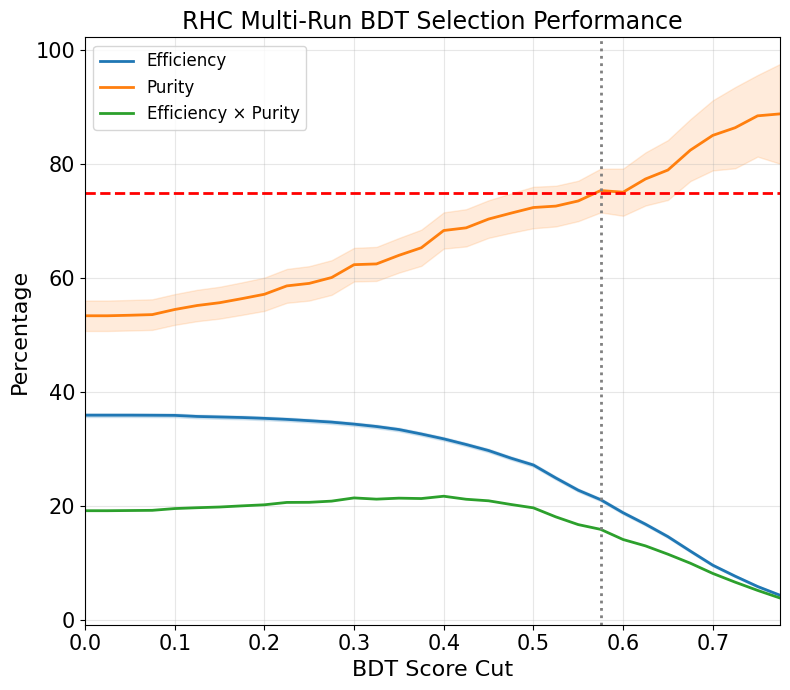

✅ BDT performance plot saved to: bdt_performance_run4a_run4b_run4c_RHC_noext_pur75.pdf

Summary:
  Best Eff×Pur at BDT score > 0.58 (purity ≥ 75%):
    Purity: 75.4%
    Efficiency: 21.2%
    Eff×Pur: 15.9%


In [37]:
# Plot BDT selection performance (purity > 75%, no linear selection comparison)

import matplotlib.pyplot as plt

print("📊 BDT Selection Performance\n")
print("=" * 70)

# Calculate BDT performance across different score cuts
x = np.arange(0, 0.8, 0.025)

# Ensure BDT_score exists
if 'BDT_score' not in df_pre_test.columns:
    print("Adding BDT scores to test set...")
    import xgboost as xgb
    dtest = xgb.DMatrix(df_pre_test[training_parameters])
    df_pre_test['BDT_score'] = bdt_model.predict(dtest)

# Generate signal array for bdt_pe function (just the weights for each signal event)
gen_data = df_pre.query('is_signal == True').weight.values
gen_intrinsic = np.ones(len(gen_data))  # For intrinsic count

perf_dict = sf.bdt_pe(df_pre_test, x, gen_data, gen_intrinsic, test_size=TRAIN_TEST_SPLIT)
pur_bdt = perf_dict['purity']
pur_err_bdt = perf_dict['purErr']
eff_bdt = perf_dict['eff']
eff_err_bdt = perf_dict['effErr']

# Find the BDT cut with purity >= 75% and maximum Eff×Pur
pur_bdt_arr = np.array(pur_bdt)
eff_bdt_arr = np.array(eff_bdt)
eff_pur = eff_bdt_arr * pur_bdt_arr / 100

# Mask for purity >= 75%
mask = pur_bdt_arr >= 75
if np.any(mask):
    best_idx = np.argmax(eff_pur * mask)
    best_cut = x[best_idx]
    print(f"BDT Performance at best Eff×Pur with purity ≥ 75% (BDT score > {best_cut:.3f}):")
    print(f"  Purity: {pur_bdt[best_idx]:.2f}% ± {pur_err_bdt[best_idx]:.2f}%")
    print(f"  Efficiency: {eff_bdt[best_idx]:.2f}% ± {eff_err_bdt[best_idx]:.2f}%")
    print(f"  Eff × Pur: {eff_pur[best_idx]:.2f}%\n")
else:
    print("⚠️ No BDT cut found with purity ≥ 75% in the scanned range.")
    best_idx = np.argmax(pur_bdt_arr)
    best_cut = x[best_idx]
    print(f"Highest purity found: {pur_bdt[best_idx]:.2f}% at BDT score > {best_cut:.3f}")

print("=" * 70)
print("\n📈 Generating BDT performance plot...\n")

# Plot
fig, ax = plt.subplots(figsize=(8, 7)) # Originally (8, 6)
ax.plot(x, eff_bdt, label='Efficiency', color='#1f77b4', linewidth=2)
ax.plot(x, pur_bdt, label='Purity', color='#ff7f0e', linewidth=2)
ax.plot(x, eff_pur, label='Efficiency × Purity', color='#2ca02c', linewidth=2)
ax.fill_between(x, eff_bdt_arr-eff_err_bdt, eff_bdt_arr+eff_err_bdt, color='#1f77b4', alpha=0.15)
ax.fill_between(x, pur_bdt_arr-pur_err_bdt, pur_bdt_arr+pur_err_bdt, color='#ff7f0e', alpha=0.15)
ax.axvline(best_cut, color='gray', linestyle=':', linewidth=2, label='_nolegend_')
ax.axhline(75, color='red', linestyle='--', linewidth=2, label='_nolegend_')
ax.set_xlabel('BDT Score Cut', fontsize=16)
ax.set_ylabel('Percentage', fontsize=16)
ax.set_title(f'{HORN_CURRENT} Multi-Run BDT Selection Performance', fontsize=17)
ax.legend(fontsize=12)
ax.tick_params(labelsize=15)
ax.grid(alpha=0.3)
ax.set_xlim(x[0], x[-1])
plt.tight_layout()

run_names_str = '_'.join([k for k, v in RUN_PERIODS.items() if v])
ext_suffix = '_noext' if not USE_EXT_IN_BDT else '_withext'
plot_filename = f'bdt_performance_{run_names_str}_{HORN_CURRENT}{ext_suffix}_pur75.pdf'
plt.savefig(plot_filename, bbox_inches='tight')
plt.show()

print(f"✅ BDT performance plot saved to: {plot_filename}")
print("\nSummary:")
print(f"  Best Eff×Pur at BDT score > {best_cut:.2f} (purity ≥ 75%):")
print(f"    Purity: {pur_bdt[best_idx]:.1f}%")
print(f"    Efficiency: {eff_bdt[best_idx]:.1f}%")
print(f"    Eff×Pur: {eff_pur[best_idx]:.1f}%")

## BDT Training Performance

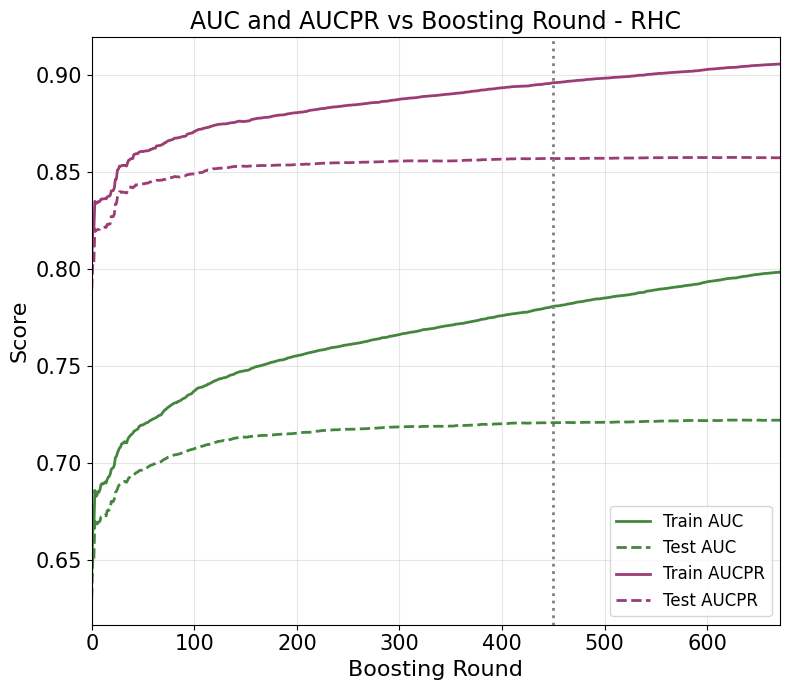

In [38]:
import matplotlib.pyplot as plt

# Use the DataFrame from the optimization step (not the final training)
# Example: bdt_metrics_df = sf.bdt_metrics(..., return_df=True)
# If you didn't save it, rerun bdt_metrics with return_df=True and assign to bdt_metrics_df

if ISRUN3:
    ROUNDS = 450
else:
    ROUNDS = 350

fig, ax = plt.subplots(figsize=(8,7))

# Plot AUC
ax.plot(bdt_metrics_df['train-auc'], label='Train AUC', color='#44863E', linestyle='-', linewidth=2)
ax.plot(bdt_metrics_df['test-auc'], label='Test AUC', color='#44863E', linestyle='--', linewidth=2)

# Plot AUCPR
ax.plot(bdt_metrics_df['train-aucpr'], label='Train AUCPR', color='#9C3C75', linestyle='-', linewidth=2)
ax.plot(bdt_metrics_df['test-aucpr'], label='Test AUCPR', color='#9C3C75', linestyle='--', linewidth=2)
ax.set_xlabel('Boosting Round', fontsize=16)
ax.set_ylabel('Score', fontsize=16)
ax.set_title(f'AUC and AUCPR vs Boosting Round - {HORN_CURRENT}', fontsize=17)
ax.tick_params(labelsize=15)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

# Mark your chosen ROUNDS
ax.axvline(ROUNDS, color='gray', linestyle=':', linewidth=2, label=f'ROUNDS = {ROUNDS}')

# Show the full range of boosting rounds attempted in optimization
ax.set_xlim(0, len(bdt_metrics_df) - 1)

plt.tight_layout()
plt.savefig(f'bdt_training_curves_{HORN_CURRENT}.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Stop notebook execution here
raise RuntimeError("⛔️ Stopping notebook here for inspection.")

## BDT Training - Step 1: Optimize Number of Rounds

First, we optimize the number of boosting rounds using AUC and AUCPR metrics with early stopping.
This follows the same approach as in selection.ipynb.

## BDT Training Workflow

Following the same approach as `selection.ipynb`:

**Step 1: Optimize Rounds** (next cell)
- Use `bdt_metrics()` with early stopping (up to 1000 rounds, stops after 50 rounds without improvement)
- Plot AUC and AUCPR curves
- Determine optimal number of boosting rounds

**Step 2: Train Final Model** (cells below)
- Set `ROUNDS` based on Step 1 results
- Train model with `main_BDT()` using optimized rounds
- Same hyperparameters as single-run BDT
- Evaluate performance and save model

In [20]:
# BDT training queries
# TRAIN ON A SUBSET OF THE DISTRIBUTION (same as selection.ipynb)
TRAIN_QUERY = BDT_LOOSE_CUTS + ' and -0.9<tksh_angle<0.9'  # Train on subset
TEST_QUERY = BDT_LOOSE_CUTS  # Test on full distribution after loose cuts

print("🎯 BDT Training Configuration:")
print(f"   Training query: {TRAIN_QUERY}")
print(f"   Test query: {TEST_QUERY}")
print(f"   Training variables: {training_parameters}")
print(f"   Use EXT in BDT: {USE_EXT_IN_BDT}")
print(f"   Train/Test split: {int((1-TRAIN_TEST_SPLIT)*100)}% train / {int(TRAIN_TEST_SPLIT*100)}% test")

🎯 BDT Training Configuration:
   Training query: swtrig_pre == 1 and slice_orig_pass_id == 1 and 10<=reco_nu_vtx_sce_x<=246 and -106<=reco_nu_vtx_sce_y<=106 and 10<=reco_nu_vtx_sce_z<=1026 and contained_fraction > 0.9 and n_showers_contained == 1 and shr_energy_tot_cali > 0.07 and n_tracks_contained > 0 and trk_energy > 0.04 and shrmoliereavg < 15 and trkpid < 0.35 and tksh_distance < 12 and -0.9<tksh_angle<0.9
   Test query: swtrig_pre == 1 and slice_orig_pass_id == 1 and 10<=reco_nu_vtx_sce_x<=246 and -106<=reco_nu_vtx_sce_y<=106 and 10<=reco_nu_vtx_sce_z<=1026 and contained_fraction > 0.9 and n_showers_contained == 1 and shr_energy_tot_cali > 0.07 and n_tracks_contained > 0 and trk_energy > 0.04 and shrmoliereavg < 15 and trkpid < 0.35 and tksh_distance < 12
   Training variables: ['shr_tkfit_dedx_Y', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_2cm_dedx_Y', 'pfng2hipfrac', 'pfng2hipavrg', 'ng2hip_r1cm', 'ng2hip_r10cm', 'pfng2shrfrac', 'pfng2shravrg', 'shrmoliereavg', 'subcluster', 'tksh_di

### BDT Hyperparameters

The hyperparameters are defined in `selection_functions.py` (both `main_BDT` and `bdt_metrics` functions):

```python
params = {
    'objective': 'binary:logistic',
    'booster': 'gbtree',
    'eta': 0.02,              # Learning rate
    'tree_method': 'exact',
    'max_depth': 3,           # Maximum tree depth
    'subsample': 0.8,         # Fraction of samples per tree
    'colsample_bytree': 1,    # Fraction of features per tree
    'silent': 1,
    'min_child_weight': 1,
    'seed': 2002,
    'gamma': 1,               # Minimum loss reduction for split
    'max_delta_step': 0,
    'scale_pos_weight': <calculated from data>,  # Signal/background ratio
    'eval_metric': ['error', 'auc', 'aucpr']
}
```

**Note:** `scale_pos_weight` is automatically calculated as the ratio of background to signal events in the training set to handle class imbalance.

In [21]:
# Prepare datasets dictionary for BDT training (same structure as selection.ipynb)
print("\n📊 Preparing datasets for BDT training...")

# Create datasets dictionary matching main_BDT() expected format
# infv: events with truth vertex in fiducial volume
# outfv: events with truth vertex outside fiducial volume  
# ext: beam-off data (NOT used when USE_EXT_IN_BDT=False)

datasets_for_bdt = {
    'infv': train_infv,      # In fiducial volume MC
    'outfv': train_outfv,    # Out of fiducial volume MC
    'ext': pd.DataFrame()     # Empty - not using EXT in training
}

print(f"✅ Datasets prepared:")
print(f"   infv: {len(datasets_for_bdt['infv']):,} events (MC with truth vtx in FV)")
print(f"   outfv: {len(datasets_for_bdt['outfv']):,} events (MC with truth vtx out of FV)")
print(f"   ext: {len(datasets_for_bdt['ext']):,} events (beam-off data - NOT used)")
print(f"\n   Total MC: {len(train_infv) + len(train_outfv):,} events")
if NUE_INTRINSIC:
    print(f"   ✅ Nue intrinsic sample included in MC")
print(f"   🚫 EXT excluded from training (USE_EXT_IN_BDT={USE_EXT_IN_BDT})")


📊 Preparing datasets for BDT training...
✅ Datasets prepared:
   infv: 247,661 events (MC with truth vtx in FV)
   outfv: 293,236 events (MC with truth vtx out of FV)
   ext: 0 events (beam-off data - NOT used)

   Total MC: 540,897 events
   ✅ Nue intrinsic sample included in MC
   🚫 EXT excluded from training (USE_EXT_IN_BDT=False)



🚀 Optimizing number of boosting rounds with early stopping...

This will train up to 1000 rounds with early_stopping_rounds=50
and plot AUC/AUCPR curves to determine optimal performance.

📊 Training set: 270,448 events
📊 Test set: 270,449 events
   Signal in training: 21,960
   Background in training: 248,488



/exp/uboone/app/users/abarnard/thesis_analysis/wc_selection/.venv/lib64/python3.9/site-packages/xgboost/core.py:723: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)
/exp/uboone/app/users/abarnard/thesis_analysis/wc_selection/.venv/lib64/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:35:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "silent" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	train-error:0.26330	train-auc:0.64390	train-aucpr:0.80485	valid-error:0.27424	valid-auc:0.63061	valid-aucpr:0.78959
[1]	train-error:0.26330	train-auc:0.66728	train-aucpr:0.82001	valid-error:0.27424	valid-auc:0.65113	valid-aucpr:0.80358
[2]	train-error:0.26330	train-auc:0.66623	train-aucpr:0.81964	valid-error:0.27424	valid-auc:0.64998	valid-aucpr:0.80314
[3]	train-error:0.26330	train-auc:0.68602	train-aucpr:0.83487	valid-error:0.27424	valid-auc:0.67026	valid-aucpr:0.82059
[4]	train-error:0.26330	train-auc:0.68290	train-aucpr:0.83386	valid-error:0.27424	valid-auc:0.66763	valid-aucpr:0.81969
[5]	train-error:0.26330	train-auc:0.68343	train-aucpr:0.83407	valid-error:0.27424	valid-auc:0.66857	valid-aucpr:0.82011
[6]	train-error:0.26330	train-auc:0.68547	train-aucpr:0.83470	valid-error:0.27424	valid-auc:0.66971	valid-aucpr:0.82043
[7]	train-error:0.26330	train-auc:0.68505	train-aucpr:0.83456	valid-error:0.27424	valid-auc:0.66971	valid-aucpr:0.82043
[8]	train-error:0.26330	train-auc:0.6864

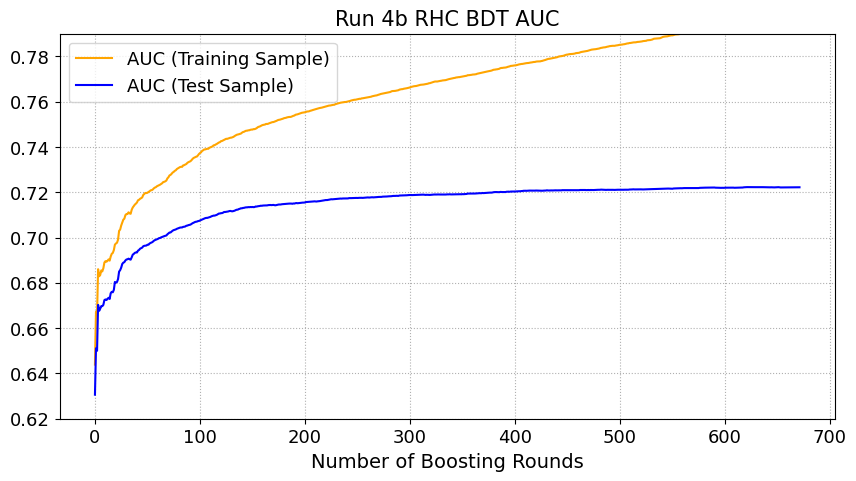

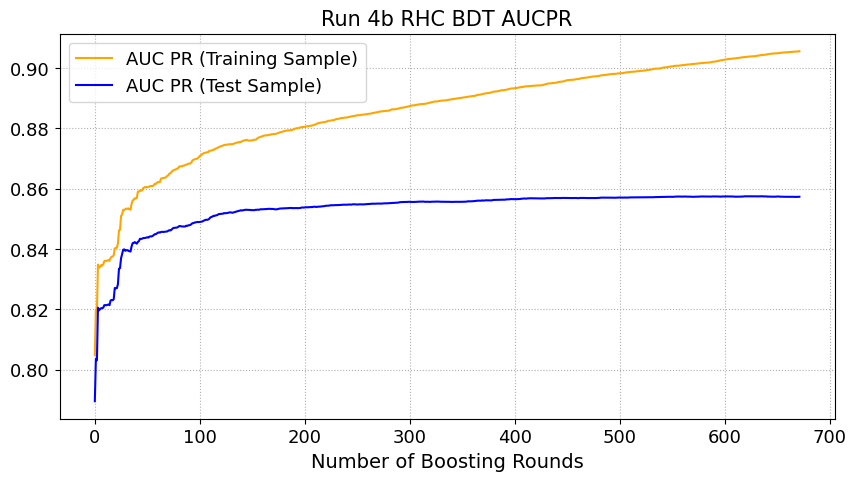


✅ Review the AUC and AUCPR plots above to determine optimal number of rounds
💡 Look for where the test (blue) curves plateau or start to diverge from train (orange)
💡 The model uses early_stopping_rounds=50, so training stops 50 rounds after best score


In [22]:
# Run bdt_metrics to optimize the number of boosting rounds
# This uses early stopping with AUC and AUCPR metrics (same as selection.ipynb)

print("\n🚀 Optimizing number of boosting rounds with early stopping...\n")
print("This will train up to 1000 rounds with early_stopping_rounds=50")
print("and plot AUC/AUCPR curves to determine optimal performance.\n")

# Combine the training data the same way main_BDT does
df_pre = sf.addRelevantColumns_flexible(datasets_for_bdt, USE_EXT_IN_BDT=USE_EXT_IN_BDT)

# Split using the same seed and stratification as main_BDT
from sklearn.model_selection import train_test_split
df_pre_train, df_pre_test = train_test_split(
    df_pre, 
    test_size=TRAIN_TEST_SPLIT, 
    random_state=17, 
    stratify=df_pre['is_signal']
)

print(f"📊 Training set: {len(df_pre_train):,} events")
print(f"📊 Test set: {len(df_pre_test):,} events")
print(f"   Signal in training: {len(df_pre_train[df_pre_train['is_signal']==True]):,}")
print(f"   Background in training: {len(df_pre_train[df_pre_train['is_signal']==False]):,}\n")

# Run bdt_metrics (uses early stopping to find optimal rounds)
metrics_df = sf.bdt_metrics(
    df_pre_train, 
    df_pre_test, 
    TRAIN_QUERY, 
    TEST_QUERY, 
    training_parameters, 
    ISRUN3, 
    save=False, 
    verbose=True  # Set to False to reduce output
)

print("\n✅ Review the AUC and AUCPR plots above to determine optimal number of rounds")
print("💡 Look for where the test (blue) curves plateau or start to diverge from train (orange)")
print("💡 The model uses early_stopping_rounds=50, so training stops 50 rounds after best score")

In [23]:
metrics_df.to_pickle(f'bdt_metrics_df_{HORN_CURRENT}_today.pkl')
print(f"✅ Saved bdt_metrics_df to bdt_metrics_df_{HORN_CURRENT}_today.pkl")

✅ Saved bdt_metrics_df to bdt_metrics_df_RHC_today.pkl


## BDT Training - Step 2: Train Final Model

Now train the final model with the optimized number of rounds (set ROUNDS below based on the plots above).

In [24]:
# Set the number of boosting rounds based on the optimization above
# Look at where the AUC/AUCPR curves plateau in the plots
ROUNDS = 450  # TODO: Update this based on the plots above!

print(f"🎯 Training final BDT model with {ROUNDS} boosting rounds...")

🎯 Training final BDT model with 450 boosting rounds...


In [25]:
# Reload selection_functions to pick up the updated bdt_raw_results function
# that now tracks training metrics (error, AUC, AUCPR)
import importlib
import backend_functions.selection_functions as sf
importlib.reload(sf)
from backend_functions.selection_functions import main_BDT

print("✅ Reloaded selection_functions module with training metrics tracking")

✅ Reloaded selection_functions module with training metrics tracking


In [26]:
# Train the BDT using the main_BDT function
# This follows the same approach as selection.ipynb
print("\n🚀 Starting final BDT training...\n")

bdt_results = main_BDT(
    datasets=datasets_for_bdt,
    train_query=TRAIN_QUERY,
    test_query=TEST_QUERY,
    rounds=ROUNDS,
    training_parameters=training_parameters,
    isrun3=ISRUN3,
    test_size=TRAIN_TEST_SPLIT,
    USE_EXT_IN_BDT=USE_EXT_IN_BDT
)

bdt_model = bdt_results['bdt_model']
bdt_results_df = bdt_results['bdt_results_df']
df_pre_train = bdt_results['df_pre_train']
df_pre_test = bdt_results['df_pre_test']
df_pre = bdt_results['df_pre']

print("\n✅ BDT training complete!")
print(f"   Model trained on {len(df_pre_train):,} events")
print(f"   Tested on {len(df_pre_test):,} events")


🚀 Starting final BDT training...

scale pos weight (ratio of negative to positive) = 0.36003024886566753


/exp/uboone/app/users/abarnard/thesis_analysis/wc_selection/.venv/lib64/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:41:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "silent" } are not used.

  warnings.warn(smsg, UserWarning)



✅ BDT training complete!
   Model trained on 270,448 events
   Tested on 270,449 events


## Evaluate Model Performance

In [27]:
# Look at training results
print("📊 BDT Training Results:")
print(f"   Training set size: {len(df_pre_train):,}")
print(f"   Test set size: {len(df_pre_test):,}")
print(f"   Signal events in training: {len(df_pre_train[df_pre_train['is_signal']==True]):,}")
print(f"   Background events in training: {len(df_pre_train[df_pre_train['is_signal']==False]):,}")

# Show some metrics from the results dataframe
if len(bdt_results_df) > 0:
    print("\n🎯 Model Performance (last 10 rounds):")
    print(bdt_results_df.tail(10))

📊 BDT Training Results:
   Training set size: 270,448
   Test set size: 270,449
   Signal events in training: 21,960
   Background events in training: 248,488

🎯 Model Performance (last 10 rounds):
     train-error  test-error  train-auc  test-auc  train-aucpr  test-aucpr
440     0.273861    0.320778   0.780804  0.720764     0.898576    0.857734
441     0.273861    0.320492   0.780923  0.720789     0.898642    0.857738
442     0.272956    0.319634   0.781096  0.720751     0.898725    0.857707
443     0.273258    0.320015   0.781227  0.720758     0.898774    0.857702
444     0.273157    0.319825   0.781313  0.720770     0.898836    0.857699
445     0.273861    0.320397   0.781412  0.720776     0.898897    0.857692
446     0.273660    0.319729   0.781460  0.720759     0.898912    0.857684
447     0.273760    0.319634   0.781565  0.720803     0.898981    0.857708
448     0.273760    0.319443   0.781700  0.720786     0.899084    0.857726
449     0.273358    0.319538   0.781850  0.720727   

🔍 Debugging bdt_results_df:
   Type: <class 'pandas.core.frame.DataFrame'>
   Shape: (450, 6)
   Columns: ['train-error', 'test-error', 'train-auc', 'test-auc', 'train-aucpr', 'test-aucpr']

First few rows:
   train-error  test-error  train-auc  test-auc  train-aucpr  test-aucpr
0     0.250226    0.272146   0.663330  0.645513     0.822937    0.805650
1     0.296892    0.316392   0.676095  0.655683     0.828183    0.809756
2     0.312079    0.334223   0.681707  0.661495     0.833114    0.815292
3     0.323041    0.348145   0.693293  0.670355     0.839775    0.821170
4     0.316906    0.343950   0.696255  0.673068     0.841336    0.823363

✅ Training curves saved to: bdt_training_curves_multirun.pdf


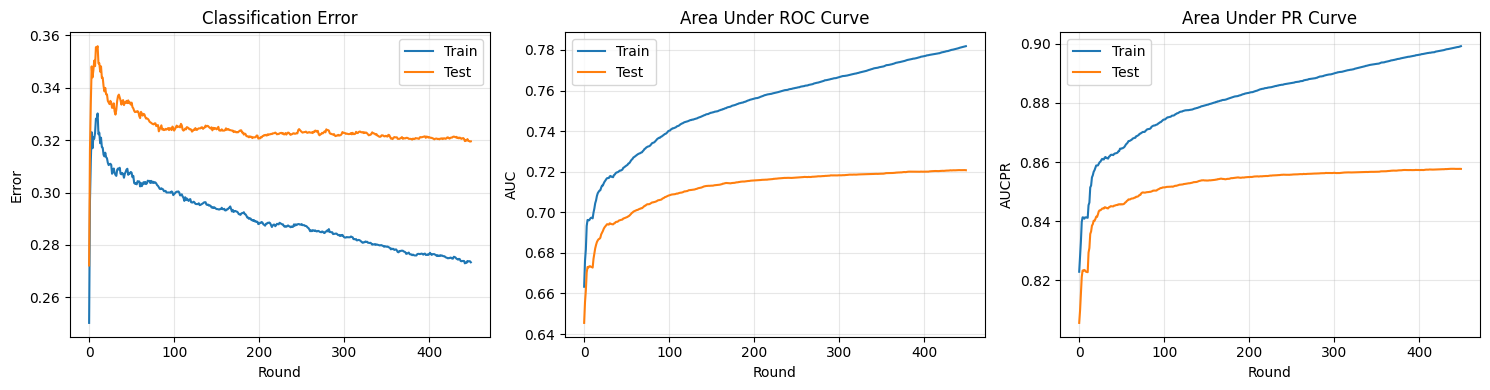

In [28]:
# Debug: Check what's in bdt_results_df
print("🔍 Debugging bdt_results_df:")
print(f"   Type: {type(bdt_results_df)}")
print(f"   Shape: {bdt_results_df.shape if hasattr(bdt_results_df, 'shape') else 'N/A'}")
print(f"   Columns: {list(bdt_results_df.columns) if hasattr(bdt_results_df, 'columns') else 'N/A'}")
if hasattr(bdt_results_df, 'head'):
    print("\nFirst few rows:")
    print(bdt_results_df.head())

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if 'train-error' in bdt_results_df.columns:
    axes[0].plot(bdt_results_df['train-error'], label='Train')
    axes[0].plot(bdt_results_df['test-error'], label='Test')
    axes[0].set_xlabel('Round')
    axes[0].set_ylabel('Error')
    axes[0].set_title('Classification Error')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No error data', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Classification Error')

if 'train-auc' in bdt_results_df.columns:
    axes[1].plot(bdt_results_df['train-auc'], label='Train')
    axes[1].plot(bdt_results_df['test-auc'], label='Test')
    axes[1].set_xlabel('Round')
    axes[1].set_ylabel('AUC')
    axes[1].set_title('Area Under ROC Curve')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No AUC data', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Area Under ROC Curve')

if 'train-aucpr' in bdt_results_df.columns:
    axes[2].plot(bdt_results_df['train-aucpr'], label='Train')
    axes[2].plot(bdt_results_df['test-aucpr'], label='Test')
    axes[2].set_xlabel('Round')
    axes[2].set_ylabel('AUCPR')
    axes[2].set_title('Area Under PR Curve')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'No AUCPR data', ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('Area Under PR Curve')

plt.tight_layout()
plt.savefig('bdt_training_curves_multirun.pdf', bbox_inches='tight')
print("\n✅ Training curves saved to: bdt_training_curves_multirun.pdf")
plt.show()

In [29]:
import pandas as pd

# OR load from pickle
bdt_metrics_df = pd.read_pickle(f'bdt_metrics_df_{HORN_CURRENT}_today.pkl')

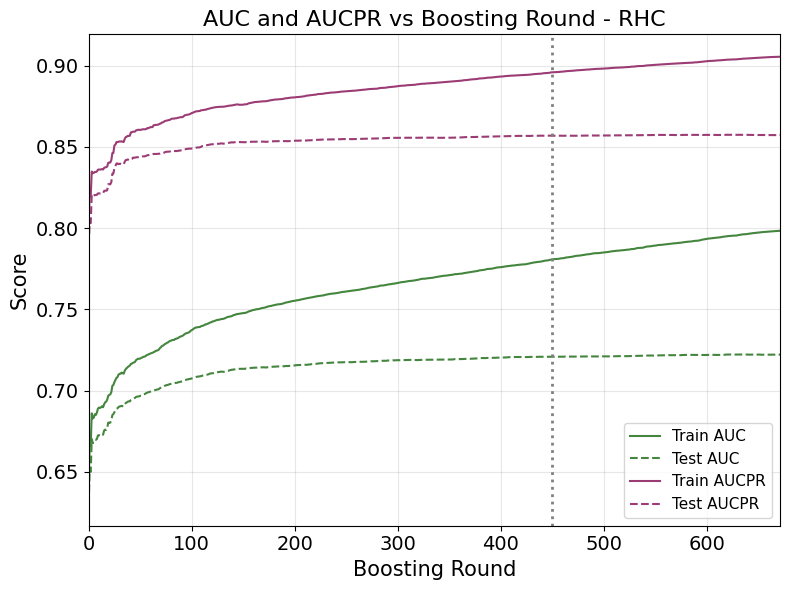

In [30]:
import matplotlib.pyplot as plt

# Use the DataFrame from the optimization step (not the final training)
# Example: bdt_metrics_df = sf.bdt_metrics(..., return_df=True)
# If you didn't save it, rerun bdt_metrics with return_df=True and assign to bdt_metrics_df

fig, ax = plt.subplots(figsize=(8, 6))

# Plot AUC
ax.plot(bdt_metrics_df['train-auc'], label='Train AUC', color='#44863E', linestyle='-')
ax.plot(bdt_metrics_df['test-auc'], label='Test AUC', color='#44863E', linestyle='--')

# Plot AUCPR
ax.plot(bdt_metrics_df['train-aucpr'], label='Train AUCPR', color='#9C3C75', linestyle='-')
ax.plot(bdt_metrics_df['test-aucpr'], label='Test AUCPR', color='#9C3C75', linestyle='--')

ax.set_xlabel('Boosting Round', fontsize=15)
ax.set_ylabel('Score', fontsize=15)
ax.set_title(f'AUC and AUCPR vs Boosting Round - {HORN_CURRENT}', fontsize=16)
ax.tick_params(labelsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Mark your chosen ROUNDS
ax.axvline(ROUNDS, color='gray', linestyle=':', linewidth=2, label=f'ROUNDS = {ROUNDS}')

# Show the full range of boosting rounds attempted in optimization
ax.set_xlim(0, len(bdt_metrics_df) - 1)

plt.tight_layout()
plt.savefig(f'bdt_training_curves_{HORN_CURRENT}.pdf', bbox_inches='tight')
plt.show()

In [31]:
import importlib
import backend_functions.selection_functions as sf
importlib.reload(sf)

<module 'backend_functions.selection_functions' from '/exp/uboone/app/users/abarnard/thesis_analysis/wc_selection/backend_functions/selection_functions.py'>

## Linear Selection vs BDT Selection Plot

In [ ]:
# # Compare BDT selection performance to linear selection
# # This follows the same approach as selection.ipynb

# print("📊 Comparing BDT vs Linear Selection Performance\n")
# print("=" * 70)

# # Define the LINEAR SELECTION (tighter cuts than BDT_LOOSE_CUTS)
# # This is the traditional selection used as baseline for comparison
# SEL_QUERY = 'swtrig_pre == 1'
# SEL_QUERY += ' and slice_orig_pass_id == 1'
# SEL_QUERY += ' and ' + reco_in_fv_query
# SEL_QUERY +=' and contained_fraction > 0.9'
# SEL_QUERY += ' and n_showers_contained == 1'
# SEL_QUERY += ' and shr_energy_tot_cali > 0.07'
# SEL_QUERY += ' and n_tracks_contained > 0'
# SEL_QUERY += ' and trk_energy > 0.04'
# SEL_QUERY += ' and shrmoliereavg < 8'  # Tighter than BDT loose cuts (15)
# SEL_QUERY += ' and trkpid < 0'          # Tighter than BDT loose cuts (0.35)
# SEL_QUERY += ' and shr_tkfit_dedx_Y < 4'
# if HORN_CURRENT == 'FHC':
#     SEL_QUERY += ' and tksh_distance < 5'
# else:
#     SEL_QUERY += ' and tksh_distance < 4'

# print("Linear Selection Query:")
# print(SEL_QUERY)
# print()

# # Calculate total signal generated (for efficiency calculation)
# # For multi-run, we need to calculate from the weighted events in our combined dataset
# # The df_pre contains all signal events from all runs, properly weighted to data POT

# # Calculate on test set
# test_df = df_pre_test

# total_signal_in_test = np.nansum(test_df.query('is_signal == True').weight)
# total_signal_in_test_intrinsic = len(test_df.query('is_signal == True'))

# print(f"Total signal generated (weighted): {total_signal_in_test:.2f}")
# print(f"Total signal generated (intrinsic count): {total_signal_in_test_intrinsic:,}\n")

# # Signal selected by linear cuts
# sig_sel_linear = np.nansum(test_df.query(SEL_QUERY + ' and is_signal==True').weight)

# # Total selected by linear cuts
# tot_sel_linear = np.nansum(test_df.query(SEL_QUERY).weight)

# # Calculate purity and efficiency for linear selection
# # No need to account for split - we're calculating on test set directly
# pur_linear = (sig_sel_linear / tot_sel_linear) * 100
# eff_linear = (sig_sel_linear / total_signal_in_test) * 100

# # Errors
# pur_err_linear = pur_linear * np.sqrt(
#     sum(test_df.query(SEL_QUERY + ' and is_signal==1').weight**2) / 
#     sum(test_df.query(SEL_QUERY + ' and is_signal==1').weight)**2 + 
#     sum(test_df.query(SEL_QUERY).weight**2) / 
#     sum(test_df.query(SEL_QUERY).weight)**2
# )
# eff_err_linear = np.sqrt((eff_linear/100) * (1 - eff_linear/100) / total_signal_in_test_intrinsic) * 100

# results_box = [pur_linear, eff_linear]
# results_box_err = [pur_err_linear, eff_err_linear]

# print("Linear Selection Performance:")
# print(f"  Purity: {pur_linear:.2f}% ± {pur_err_linear:.2f}%")
# print(f"  Efficiency: {eff_linear:.2f}% ± {eff_err_linear:.2f}%")
# print(f"  Eff × Pur: {(eff_linear * pur_linear / 100):.2f}%\n")

# # Calculate BDT performance across different score cuts
# # x values for BDT score cuts
# x = np.arange(0, 0.8, 0.025)

# # Use the bdt_pe function to calculate efficiency and purity at different BDT cuts
# # This requires df_pre_test to have BDT_score column already
# if 'BDT_score' not in df_pre_test.columns:
#     print("Adding BDT scores to test set...")
#     import xgboost as xgb
#     dtest = xgb.DMatrix(df_pre_test[training_parameters])
#     df_pre_test['BDT_score'] = bdt_model.predict(dtest)

# # Generate signal array for bdt_pe function (just the weights for each signal event)
# gen_data = df_pre.query('is_signal == True').weight.values
# gen_intrinsic = np.ones(len(gen_data))  # For intrinsic count

# perf_dict = sf.bdt_pe(df_pre_test, x, gen_data, gen_intrinsic, test_size=TRAIN_TEST_SPLIT)
# pur_bdt = perf_dict['purity']
# pur_err_bdt = perf_dict['purErr']
# eff_bdt = perf_dict['eff']
# eff_err_bdt = perf_dict['effErr']

# # Find the BDT cut that gives similar purity to linear selection
# purity_diff = np.abs(np.array(pur_bdt) - pur_linear)
# similar_pur_idx = np.argmin(purity_diff)
# similar_pur_cut = x[similar_pur_idx]

# print(f"BDT Performance at similar purity to linear selection (BDT score > {similar_pur_cut:.3f}):")
# print(f"  Purity: {pur_bdt[similar_pur_idx]:.2f}% ± {pur_err_bdt[similar_pur_idx]:.2f}%")
# print(f"  Efficiency: {eff_bdt[similar_pur_idx]:.2f}% ± {eff_err_bdt[similar_pur_idx]:.2f}%")
# print(f"  Eff × Pur: {(eff_bdt[similar_pur_idx] * pur_bdt[similar_pur_idx] / 100):.2f}%\n")

# if eff_bdt[similar_pur_idx] > eff_linear:
#     improvement = ((eff_bdt[similar_pur_idx] - eff_linear) / eff_linear) * 100
#     print(f"💡 BDT improves efficiency by {improvement:.1f}% at similar purity!\n")
# else:
#     print(f"⚠️  At similar purity, linear selection has higher efficiency\n")

# print("=" * 70)

# # Plot comparison using bdt_box_plot
# print("\n📈 Generating comparison plot...\n")

# run_names_str = '_'.join([k for k, v in RUN_PERIODS.items() if v])
# ext_suffix = '_noext' if not USE_EXT_IN_BDT else '_withext'

# sf.bdt_box_plot(
#     [pur_bdt, pur_err_bdt, eff_bdt, eff_err_bdt],  # BDT results
#     x,  # x values (BDT score cuts)
#     ISRUN3,  # Is this Run 3?
#     results_box=results_box,  # Linear selection results
#     results_box_err=results_box_err,  # Linear selection errors
#     save=True,
#     save_label=f'{run_names_str}_{HORN_CURRENT}{ext_suffix}',
#     title=f'{HORN_CURRENT} Multi-Run BDT vs Linear Selection',
#     target_purity=75
# )

# print("✅ Comparison plot saved!")
# print("\nComparison Summary:")
# print(f"  Linear selection: {pur_linear:.1f}% purity, {eff_linear:.1f}% efficiency")
# print(f"  BDT at ~{pur_bdt[similar_pur_idx]:.1f}% purity: {eff_bdt[similar_pur_idx]:.1f}% efficiency")

📊 BDT Selection Performance

Adding BDT scores to test set...
BDT Performance at best Eff×Pur with purity ≥ 75% (BDT score > 0.575):
  Purity: 75.39% ± 3.84%
  Efficiency: 21.15% ± 0.28%
  Eff × Pur: 15.95%


📈 Generating BDT performance plot...



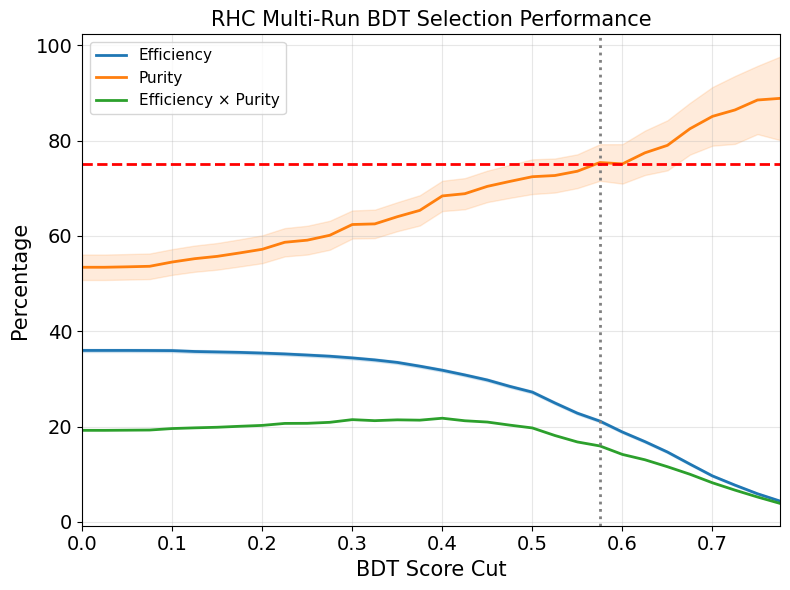

✅ BDT performance plot saved to: bdt_performance_run4a_run4b_run4c_RHC_noext_pur75.pdf

Summary:
  Best Eff×Pur at BDT score > 0.58 (purity ≥ 75%):
    Purity: 75.4%
    Efficiency: 21.2%
    Eff×Pur: 15.9%


In [32]:
# Plot BDT selection performance (purity > 75%, no linear selection comparison)

import matplotlib.pyplot as plt

print("📊 BDT Selection Performance\n")
print("=" * 70)

# Calculate BDT performance across different score cuts
x = np.arange(0, 0.8, 0.025)

# Ensure BDT_score exists
if 'BDT_score' not in df_pre_test.columns:
    print("Adding BDT scores to test set...")
    import xgboost as xgb
    dtest = xgb.DMatrix(df_pre_test[training_parameters])
    df_pre_test['BDT_score'] = bdt_model.predict(dtest)

# Generate signal array for bdt_pe function (just the weights for each signal event)
gen_data = df_pre.query('is_signal == True').weight.values
gen_intrinsic = np.ones(len(gen_data))  # For intrinsic count

perf_dict = sf.bdt_pe(df_pre_test, x, gen_data, gen_intrinsic, test_size=TRAIN_TEST_SPLIT)
pur_bdt = perf_dict['purity']
pur_err_bdt = perf_dict['purErr']
eff_bdt = perf_dict['eff']
eff_err_bdt = perf_dict['effErr']

# Find the BDT cut with purity >= 75% and maximum Eff×Pur
pur_bdt_arr = np.array(pur_bdt)
eff_bdt_arr = np.array(eff_bdt)
eff_pur = eff_bdt_arr * pur_bdt_arr / 100

# Mask for purity >= 75%
mask = pur_bdt_arr >= 75
if np.any(mask):
    best_idx = np.argmax(eff_pur * mask)
    best_cut = x[best_idx]
    print(f"BDT Performance at best Eff×Pur with purity ≥ 75% (BDT score > {best_cut:.3f}):")
    print(f"  Purity: {pur_bdt[best_idx]:.2f}% ± {pur_err_bdt[best_idx]:.2f}%")
    print(f"  Efficiency: {eff_bdt[best_idx]:.2f}% ± {eff_err_bdt[best_idx]:.2f}%")
    print(f"  Eff × Pur: {eff_pur[best_idx]:.2f}%\n")
else:
    print("⚠️ No BDT cut found with purity ≥ 75% in the scanned range.")
    best_idx = np.argmax(pur_bdt_arr)
    best_cut = x[best_idx]
    print(f"Highest purity found: {pur_bdt[best_idx]:.2f}% at BDT score > {best_cut:.3f}")

print("=" * 70)
print("\n📈 Generating BDT performance plot...\n")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, eff_bdt, label='Efficiency', color='#1f77b4', linewidth=2)
ax.plot(x, pur_bdt, label='Purity', color='#ff7f0e', linewidth=2)
ax.plot(x, eff_pur, label='Efficiency × Purity', color='#2ca02c', linewidth=2)
ax.fill_between(x, eff_bdt_arr-eff_err_bdt, eff_bdt_arr+eff_err_bdt, color='#1f77b4', alpha=0.15)
ax.fill_between(x, pur_bdt_arr-pur_err_bdt, pur_bdt_arr+pur_err_bdt, color='#ff7f0e', alpha=0.15)
ax.axvline(best_cut, color='gray', linestyle=':', linewidth=2, label='_nolegend_')
ax.axhline(75, color='red', linestyle='--', linewidth=2, label='_nolegend_')
ax.set_xlabel('BDT Score Cut', fontsize=15)
ax.set_ylabel('Percentage', fontsize=15)
ax.set_title(f'{HORN_CURRENT} Multi-Run BDT Selection Performance', fontsize=15)
ax.legend(fontsize=11)
ax.tick_params(labelsize=14)
ax.grid(alpha=0.3)
ax.set_xlim(x[0], x[-1])
plt.tight_layout()

run_names_str = '_'.join([k for k, v in RUN_PERIODS.items() if v])
ext_suffix = '_noext' if not USE_EXT_IN_BDT else '_withext'
plot_filename = f'bdt_performance_{run_names_str}_{HORN_CURRENT}{ext_suffix}_pur75.pdf'
plt.savefig(plot_filename, bbox_inches='tight')
plt.show()

print(f"✅ BDT performance plot saved to: {plot_filename}")
print("\nSummary:")
print(f"  Best Eff×Pur at BDT score > {best_cut:.2f} (purity ≥ 75%):")
print(f"    Purity: {pur_bdt[best_idx]:.1f}%")
print(f"    Efficiency: {eff_bdt[best_idx]:.1f}%")
print(f"    Eff×Pur: {eff_pur[best_idx]:.1f}%")

In [33]:
# Detailed numerical comparison at different BDT score cuts
print("\n" + "=" * 90)
print("DETAILED NUMERICAL COMPARISON: BDT vs Linear Selection")
print("=" * 90)

# Create a comparison table
import pandas as pd

# Select key BDT score points to evaluate
score_points = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
comparison_data = []

for score in score_points:
    # Find closest index in x array
    idx = np.argmin(np.abs(x - score))
    actual_score = x[idx]
    
    # Get BDT performance at this score
    bdt_pur = pur_bdt[idx]
    bdt_eff = eff_bdt[idx]
    bdt_metric = bdt_pur * bdt_eff / 100
    
    # Calculate gains relative to linear selection
    pur_gain = bdt_pur - pur_linear
    eff_gain = bdt_eff - eff_linear
    metric_gain = bdt_metric - (pur_linear * eff_linear / 100)
    
    comparison_data.append({
        'BDT Score >': f'{actual_score:.2f}',
        'BDT Purity (%)': f'{bdt_pur:.1f}',
        'BDT Efficiency (%)': f'{bdt_eff:.1f}',
        'Eff×Pur': f'{bdt_metric:.1f}',
        'ΔPurity': f'{pur_gain:+.1f}',
        'ΔEfficiency': f'{eff_gain:+.1f}',
        'ΔEff×Pur': f'{metric_gain:+.1f}'
    })

# Add linear selection as reference row
comparison_data.insert(0, {
    'BDT Score >': 'Linear Sel.',
    'BDT Purity (%)': f'{pur_linear:.1f}',
    'BDT Efficiency (%)': f'{eff_linear:.1f}',
    'Eff×Pur': f'{pur_linear * eff_linear / 100:.1f}',
    'ΔPurity': '—',
    'ΔEfficiency': '—',
    'ΔEff×Pur': '—'
})

comparison_df = pd.DataFrame(comparison_data)

print("\nComparison Table (Δ = BDT - Linear):")
print(comparison_df.to_string(index=False))

# Find the "sweet spot" - maximum Eff×Pur gain
best_idx = None
best_gain = -float('inf')
for i, score in enumerate(score_points):
    idx = np.argmin(np.abs(x - score))
    bdt_metric = pur_bdt[idx] * eff_bdt[idx] / 100
    lin_metric = pur_linear * eff_linear / 100
    gain = bdt_metric - lin_metric
    if gain > best_gain:
        best_gain = gain
        best_idx = idx

print("\n" + "=" * 90)
print("RECOMMENDATIONS:")
print("=" * 90)

# 1. Best Eff×Pur
print(f"\n1. Maximum Eff×Pur gain:")
print(f"   BDT score > {x[best_idx]:.3f}")
print(f"   Purity: {pur_bdt[best_idx]:.1f}%, Efficiency: {eff_bdt[best_idx]:.1f}%")
print(f"   Eff×Pur gain: +{best_gain:.1f} percentage points")

# 2. At similar purity to linear
print(f"\n2. At similar purity to linear selection (~{pur_linear:.0f}%):")
print(f"   BDT score > {similar_pur_cut:.3f}")
print(f"   Purity: {pur_bdt[similar_pur_idx]:.1f}%, Efficiency: {eff_bdt[similar_pur_idx]:.1f}%")
if eff_bdt[similar_pur_idx] > eff_linear:
    rel_gain = ((eff_bdt[similar_pur_idx] - eff_linear) / eff_linear) * 100
    print(f"   Efficiency gain: +{eff_bdt[similar_pur_idx] - eff_linear:.1f} percentage points ({rel_gain:.1f}% relative)")
else:
    print(f"   Efficiency loss: {eff_bdt[similar_pur_idx] - eff_linear:.1f} percentage points")

# 3. High purity option (if user wants cleaner sample)
high_pur_target = 70.0  # Target 70% purity
high_pur_idx = np.argmin(np.abs(np.array(pur_bdt) - high_pur_target))
print(f"\n3. High-purity option (~{pur_bdt[high_pur_idx]:.0f}% purity):")
print(f"   BDT score > {x[high_pur_idx]:.3f}")
print(f"   Purity: {pur_bdt[high_pur_idx]:.1f}%, Efficiency: {eff_bdt[high_pur_idx]:.1f}%")
print(f"   Trade-off: +{pur_bdt[high_pur_idx] - pur_linear:.1f} purity, {eff_bdt[high_pur_idx] - eff_linear:.1f} efficiency")

print("\n" + "=" * 90)


DETAILED NUMERICAL COMPARISON: BDT vs Linear Selection


NameError: name 'pur_linear' is not defined

## Save Trained Model

Save the trained BDT model with a descriptive name.

In [34]:
# Create model filename based on configuration
run_names = '_'.join([k for k, v in RUN_PERIODS.items() if v])
ext_suffix = '_noext' if not USE_EXT_IN_BDT else '_withext'
horn_suffix = f'_{HORN_CURRENT}'
model_filename = f'BDT_models/bdt_{run_names}{horn_suffix}{ext_suffix}_290126.model'

# Save model
bdt_model.save_model(model_filename)
print(f"✅ Model saved to: {model_filename}")

# Save training parameters as well
import pickle

training_info = {
    'model_path': model_filename,
    'horn_current': HORN_CURRENT,
    'training_variables': training_parameters,
    'run_periods': RUN_PERIODS,
    'train_test_split': TRAIN_TEST_SPLIT,
    'event_split_seed': EVENT_SPLIT_SEED,
    'use_ext_in_bdt': USE_EXT_IN_BDT,
    'train_query': TRAIN_QUERY,
    'test_query': TEST_QUERY,
    'rounds': ROUNDS,
    'isrun3': ISRUN3,
    'nue_intrinsic': NUE_INTRINSIC
}

info_filename = model_filename.replace('.model', '_info.pkl')
with open(info_filename, 'wb') as f:
    pickle.dump(training_info, f)
    
print(f"✅ Training info saved to: {info_filename}")
    
print(f"✅ Training info saved to: {info_filename}")

✅ Model saved to: BDT_models/bdt_run4a_run4b_run4c_RHC_noext_290126.model
✅ Training info saved to: BDT_models/bdt_run4a_run4b_run4c_RHC_noext_290126_info.pkl
✅ Training info saved to: BDT_models/bdt_run4a_run4b_run4c_RHC_noext_290126_info.pkl


/exp/uboone/app/users/abarnard/thesis_analysis/wc_selection/.venv/lib64/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:46:49] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


## Save Training Data (Optional)

Save the training data for later analysis (SHAP, etc.)

In [35]:
# Save training data
training_data = {
    'df_pre_train': df_pre_train,
    'df_pre_test': df_pre_test,
    'df_pre': bdt_results['df_pre'],
    'training_info': training_info
}

training_data_filename = f'BDT_training_data/training_data_{run_names}_multirun{ext_suffix}_290126.pkl'

with open(training_data_filename, 'wb') as f:
    pickle.dump(training_data, f)
    
print(f"✅ Training data saved to: {training_data_filename}")
print(f"   Train: {len(df_pre_train):,} events")
print(f"   Test: {len(df_pre_test):,} events")

✅ Training data saved to: BDT_training_data/training_data_run4a_run4b_run4c_multirun_noext_290126.pkl
   Train: 270,448 events
   Test: 270,449 events


## Summary

Training complete! The model is now ready to use in your selection analysis.

In [ ]:
print("=" * 70)
print("🎉 BDT TRAINING COMPLETE!")
print("=" * 70)
print(f"\n📁 Model saved to: {model_filename}")
print(f"📁 Training info saved to: {info_filename}")
print(f"📁 Training data saved to: {training_data_filename}")
print(f"\n📊 Training Summary:")
print(f"   Run periods: {[k for k, v in RUN_PERIODS.items() if v]}")
print(f"   Total training events: {len(df_pre_train):,}")
print(f"   Total test events: {len(df_pre_test):,}")
print(f"   Training variables: {len(training_parameters)}")
print(f"   Boosting rounds: {ROUNDS}")
print(f"\n💡 Next Steps:")
print(f"   1. Update top.py to point to: {model_filename}")
print(f"   2. Use selection.ipynb to analyze individual run periods")
print(f"   3. The same BDT model will be applied consistently to all runs")
print("=" * 70)

## SHAP Analysis

Generate SHAP (SHapley Additive exPlanations) plot to understand feature importance.

In [ ]:
import shap

print("🔬 Setting up SHAP analysis...")

# Prepare test data for SHAP
X_test = df_pre_test[training_parameters]
y_test = df_pre_test['is_signal']

# Create SHAP explainer
explainer = shap.TreeExplainer(bdt_model)

print("✅ SHAP setup complete!")
print(f"   Test samples: {len(X_test):,}")
print(f"   Features: {len(training_parameters)}")

In [ ]:
import numpy as np

print("🧹 Cleaning data for SHAP analysis...")

# Step 1: Replace infinite values (±inf) with NaN
X_test_clean = X_test.replace([np.inf, -np.inf], np.nan)

# Step 2: Detect float overflow placeholder values (~3.4e38)
float32_max = np.finfo(np.float32).max
mask_overflow = np.abs(X_test_clean) > (0.1 * float32_max)

# Step 3: Replace overflow values with NaN
X_test_clean[mask_overflow] = np.nan

# Step 4: Fill NaN values with median
for col in X_test_clean.columns:
    if X_test_clean[col].isna().any():
        median_val = X_test_clean[col].median()
        X_test_clean[col] = X_test_clean[col].fillna(median_val)

# Step 5: Confirm everything is finite
if not np.isfinite(X_test_clean.to_numpy()).all():
    print("⚠️ Non-finite values remain! Double-check preprocessing.")
else:
    print("✅ Data cleaned: all values finite and within safe range.")

# Use cleaned dataset
X_test = X_test_clean

print(f"   Cleaned {len(X_test):,} test samples")

### SHAP Beeswarm Plot

Generate the beeswarm plot showing feature importance and directionality.

In [ ]:
# SHAP Beeswarm Plot with Direction Labels
import shap
import matplotlib.pyplot as plt
import numpy as np

try:
    # Check if we have everything needed
    if 'explainer' in locals() and explainer is not None and 'X_test' in locals() and X_test is not None:
        print("Generating SHAP beeswarm plot...")
        
        # For computational efficiency, use a sample of test data
        sample_size = min(277005, len(X_test))
        X_sample = X_test.sample(n=sample_size, random_state=42)
        
        print(f"Computing SHAP values for {sample_size} samples...")
        shap_values = explainer.shap_values(X_sample)
        
        # Create the beeswarm plot
        plt.figure(figsize=(12, 8))
        shap.plots.beeswarm(
            shap.Explanation(
                values=shap_values if not isinstance(shap_values, list) else shap_values[0],
                data=X_sample.values,
                feature_names=training_parameters
            ),
            max_display=15,
            show=False
        )
        
        # --- Modify tick label font ---
        ax = plt.gca()
        for label in ax.get_yticklabels():
            label.set_fontfamily('monospace')
            label.set_fontsize(11)
        
        # --- Add custom axis and colorbar labels ---
        plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
        fig = plt.gcf()
        axes = fig.get_axes()
        if len(axes) > 1:
            cbar = axes[-1]
            cbar.set_ylabel("Feature Value", fontsize=12)
        
        # --- Title ---
        run_names_str = '_'.join([k for k, v in RUN_PERIODS.items() if v])
        plt.title(f'SHAP Beeswarm Plot - {HORN_CURRENT} Multi-Run BDT', fontsize=12)
        
        # --- Add custom "direction" text labels ---
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        
        # Add text slightly below the x-axis limits
        y_pos = y_min + 0.5  # adjust if text overlaps or is too far
        
        ax.text(x_min, y_pos, "← Away from Signal", fontsize=11, ha='left', va='top', color='dimgray')
        ax.text(x_max, y_pos, "Towards Signal →", fontsize=11, ha='right', va='top', color='dimgray')
        
        # --- Layout and save ---
        plt.tight_layout()
        
        # Save with descriptive filename
        shap_filename = f'shap_beeswarm_{run_names_str}_{HORN_CURRENT}{ext_suffix}.pdf'
        plt.savefig(shap_filename, bbox_inches='tight')
        plt.show()
        
        print("✅ SHAP beeswarm plot generated successfully!")
        print(f"   Saved to: {shap_filename}")
        print("This plot shows:")
        print("- Features ordered by importance (top to bottom)")
        print("- Each dot represents one sample")
        print("- X-axis shows SHAP value (impact on model output)")
        print("- Color indicates feature value (red=high, blue=low)")
        print("- Direction labels indicate movement away/towards the signal")
        
    else:
        print("❌ Missing required data for beeswarm plot")
        
except Exception as e:
    print(f"Error generating beeswarm plot: {e}")
    import traceback
    traceback.print_exc()